# [스프린트 미션 5] Baseline — CNN 오토인코더로 문서 복원하기 (+심화: ECG 이상 탐지)

- **Part 1 (기본 미션)**: 손상된 문서 이미지를 복원하는 CNN 오토인코더
- **Part 2 (심화, 채점 제외)**: 정상 심전도만 학습해 이상 심박을 찾아내는 LSTM 오토인코더


In [1]:
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF

from PIL import Image
from torch.utils.data import Dataset, DataLoader

# device = "cuda" if torch.cuda.is_available() else "cpu"     # 맥에서 사용 불가...
device = "mps" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
print("PyTorch:", torch.__version__, "| device:", device)

PyTorch: 2.14.0 | device: cpu


---
# Part 1. 손상된 문서 복원 — CNN 오토인코더

train(손상 이미지)과 train_cleaned(원본 이미지)를 한 쌍으로 학습합니다.
손상 이미지를 입력하면 원본에 가까운 이미지를 출력하도록 인코더-디코더를 학습시키는 구조예요.

## 제공된 Baseline 코드 확인

## 1-1. 데이터 준비
Kaggle에서 데이터를 내려받습니다. 두 가지 준비가 필요해요.
1. [대회 페이지](https://www.kaggle.com/competitions/denoising-dirty-documents)에서 **Join Competition**을 눌러 규칙에 동의합니다. (동의하지 않으면 다운로드가 거부됩니다)
2. Kaggle > Settings > API에서 **Create New Token**으로 `kaggle.json`을 발급받아 두세요.

In [3]:
# kaggle.json을 업로드하세요.
# from google.colab import files
# files.upload()

!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle competitions download -c denoising-dirty-documents
!unzip -q denoising-dirty-documents.zip -d data
!cd data && unzip -q train.zip && unzip -q train_cleaned.zip && unzip -q test.zip
!ls data

cp: kaggle.json: No such file or directory
100%|█████████████████████████████████████| 35.7M/35.7M [00:04<00:00, 7.80MB/s]

sampleSubmission.csv.zip train                    train_cleaned.zip
test                     train.zip
test.zip                 train_cleaned


## 1-2. Dataset 구성
이미지 크기가 두 종류(420×540, 258×540)라서, 학습할 때는 **같은 위치에서 128×128 패치를 잘라** 손상/원본 쌍으로 사용합니다.
패치 단위로 학습하면 이미지 크기를 신경 쓰지 않아도 되고, 한 이미지에서 매번 다른 부분을 보게 되어 데이터가 늘어나는 효과도 있어요.

In [ ]:
# 손상된 문서 사진과 깨끗한 정답 사진에서 똑같은 위치를 128×128 크기로 잘라서 학습용 한 쌍으로 만듦

class DirtyDocsDataset(Dataset):
    """손상 이미지와 원본 이미지에서 같은 위치의 패치를 한 쌍으로 돌려줍니다."""

    def __init__(self, dirty_dir, clean_dir, crop_size=128):
        self.dirty_dir = dirty_dir                      # 손상된 이미지가 저장된 폴더 경로
        self.clean_dir = clean_dir                      # 깨끗한 이미지가 저장된 폴더 경로
        self.files = sorted(os.listdir(dirty_dir))      # 손상 이미지 폴더에 들어 있는 파일 이름을 정렬해서 저장
        self.crop_size = crop_size                      # 이미지에서 잘라낼 정사각형 영역의 한 번 길이

    def __len__(self):
        return len(self.files)                          # 데이터셋에 들어있는 전체 이미지 개수를 반환

    def __getitem__(self, idx):
        name = self.files[idx]                          # idx번째 이미지의 파일 이름을 가져옴
        dirty = Image.open(os.path.join(self.dirty_dir, name)).convert("L")     # 손상 이미지 폴더에서 idx 번째 이미지를 열고 흑백으로 변환
        clean = Image.open(os.path.join(self.clean_dir, name)).convert("L")     # 깨끗 이미지 폴더에서 같은 이름 이미지를 열고 흑백으로 변환

        # 두 이미지에서 '같은 위치'를 잘라야 하므로 crop 좌표를 직접 뽑습니다.
        # 비교하는 대상이 같아야함 위치 다른것 비교 해봐짜 뭐해..
        cs = self.crop_size                             # 잘라낼 크기
        top = random.randint(0, dirty.height - cs)      # 이미지를 자르기 시작할 세로 위치 무작위로 선택
        left = random.randint(0, dirty.width - cs)      # 이미지를 자르기 시작할 가로 위치 무작위로 선택

        # 손상 이미지에서 선택한 위치를 128 * 128로 자른 후
        # PyTorch가 처리할 수 있는 Tensor로 변환
        # (1, 128, 128), 0~1
        dirty = TF.to_tensor(TF.crop(dirty, top, left, cs, cs))
        # 깨끗한 이미지도 손상 이미지와 완전히 같은 위치로 자름  
        clean = TF.to_tensor(TF.crop(clean, top, left, cs, cs))
        # 손상 이미지 조각은 모델 입력,
        # 깨끗한 이미지 조각은 모델이 맞혀야 할 정답으로 반환
        return dirty, clean


# 손상 이미지 폴더와 깨끗한 이미지 폴더를 이용해 데이터셋 생성
train_dataset = DirtyDocsDataset("data/train", "data/train_cleaned")
# 데이터셋에서 한 번에 16개씩 꺼내도록 설정
# shuffle=True이므로 매 epoch마다 이미지 순서를 섞음
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
# __len__()이 반환하는 전체 이미지 개수 출력
print("훈련 이미지 수:", len(train_dataset))

훈련 이미지 수: 144


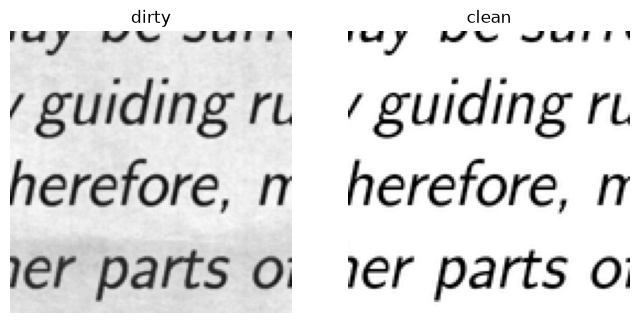

In [ ]:
# 손상/원본 쌍이 잘 만들어졌는지 확인

dirty, clean = train_dataset[0]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
# ; : 한줄에 명령문 한줄로 사용 가능함
axes[0].imshow(dirty.squeeze(), cmap="gray"); axes[0].set_title("dirty")
axes[1].imshow(clean.squeeze(), cmap="gray"); axes[1].set_title("clean")
for ax in axes: ax.axis("off")
plt.show()

## 1-3. CNN 오토인코더 설계
`Conv2d`(stride=2)로 크기를 절반씩 줄이며 특징을 압축하고, `ConvTranspose2d`로 다시 원래 크기까지 복원합니다.
층마다 텐서 크기가 어떻게 변하는지 주석으로 적어 두세요. 인코더와 디코더의 크기가 어긋나는 문제가 이 미션에서 가장 자주 만나는 에러입니다.

In [ ]:
# 손상된 이미지 dirty를 받아서 깨끗한 이미지 clean처럼 복원하는 CNN 기반 오토인코더

class ConvDenoiser(nn.Module):
    def __init__(self):
        super().__init__()                 # nn.Modul의 기본 기능 초기화
        # Encoder:
        # 이미지의 가로 세로 길이를 줄이면서 특징 추출
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),   # (1, 128, 128) -> (32, 64, 64)
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # (32, 64, 64) -> (64, 32, 32)
            nn.ReLU(),
        )
        # Decoder:
        # 추출한 특징으로부터 원래 크기의 이미지 복원
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # (64, 32, 32) -> (32, 64, 64)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),   # (32, 64, 64) -> (1, 128, 128)
            nn.Sigmoid(),  # 픽셀 값을 0~1 범위로
        )

    def forward(self, x):
        # 반.환. 추출한 특징을 Decoder에 넣어 깨끗한 이미지로 복원(손상 이미지를 Encoder에 넣어 특징 추출)
        return self.decoder(self.encoder(x))


# 모델 생성 후 CPU 또는 GPU로 이동
model = ConvDenoiser().to(device)
# 모델이 어떤 층으로 구성되어 있는지 확인
print(model)

ConvDenoiser(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): Sigmoid()
  )
)


In [ ]:
# 손상 이미지 dirty를 모델에 넣고, 모델이 복원한 restored와 깨끗한 정답 clean의 차이를 계산하여 모델의 가중치를 수정

criterion = nn.MSELoss()                                    # 손실함수 설정 - MSE
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # Optimizer 설정 - 가중치 수정 역할

EPOCHS = 30
for epoch in range(EPOCHS):
    # 학습 모드
    model.train()
    # epoch 손실 초기화
    epoch_loss = 0.0

    # 배치 단위 반복 : batch_size=16
    for dirty, clean in train_loader:
        # 데이터를 CPU 또는 GPU로 이동
        dirty, clean = dirty.to(device), clean.to(device)

        # 이전 기울기 초기화
        optimizer.zero_grad()

        # 순전파
        restored = model(dirty)

        # 손실 계산
        loss = criterion(restored, clean)

        # 역전파 : 새로운 기울기 계산
        loss.backward()

        # 역전파에서 계산한 기울기를 사용해 가중치 수정
        optimizer.step()

        # 배치 손실 누적 : 왜 곱하나?? -> 마지막 배치가 4개라서.. 마지막에 전체 이미지 개수로 나누면 이미지 개수를 고려한 평균을 구할 수 있으!!
        epoch_loss += loss.item() * len(dirty)
        
    if (epoch + 1) % 5 == 0:
        # 평균 손실 출력 : 에폭 번호 세 자리에 맞춰 출력
        print(f"epoch {epoch + 1:3d} | loss {epoch_loss / len(train_dataset):.5f}")

epoch   5 | loss 0.00659
epoch  10 | loss 0.00621
epoch  15 | loss 0.00547
epoch  20 | loss 0.00512
epoch  25 | loss 0.00469
epoch  30 | loss 0.00430


## 1-4. 전체 이미지 복원과 평가
학습은 128×128 패치로 했지만, 합성곱 모델은 입력 크기가 달라도 동작합니다.
다만 stride=2 층을 두 번 지나므로 가로/세로가 4의 배수여야 해요. 4의 배수가 아닌 이미지(258×540)는 가장자리를 패딩했다가 복원 후 잘라냅니다.

RMSE: 0.0474


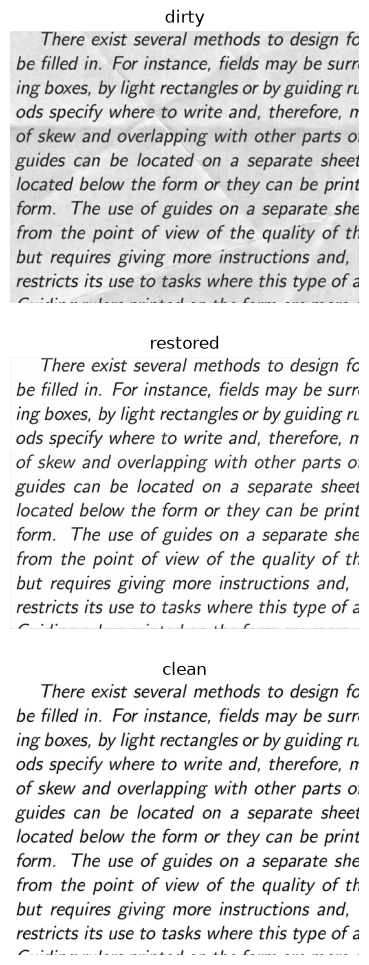

In [ ]:
# 이미지 한 장 전체를 넣어 복원 결과를 확인하는 코드

def denoise_full_image(model, img_tensor, multiple=4):
    """크기가 4의 배수가 아니면 오른쪽/아래를 패딩한 뒤 복원하고, 원래 크기로 되돌립니다."""
    # 크기가 127처럼 애매하면 축소 과정에서 반올림 문제가 생겨서 출력 크기가 입력 크기와 달라질 수 있음

    # 이미지 모양 가져오기
    # 채널이 _ 인 이유 : 받기는 하지만 이후에 사용하지 않기에....
    _, h, w = img_tensor.shape

    # 높이, 너비에 필요한 패딩 계산
    pad_h = (multiple - h % multiple) % multiple
    pad_w = (multiple - w % multiple) % multiple

    # 배치 차원 추가 후 패딩
    #    4개의 배치 차원이 필요해서 차원 추가  이미지 오른쪽 아래로 패딩 추가  패딩 영역을 단순히 0으로 채우는게 아닐 이미지 가장자리 내용을 거울처럼 반사해서 채움
    x = F.pad(img_tensor.unsqueeze(0), (0, pad_w, 0, pad_h), mode="reflect")

    # 평가 모드
    model.eval()
    # 기울기 계산 끄기 : 모델 학습이 목적이 아닌 보권 결과만 확인 -> 메모리 적게 사용 / 계산 속도 빨라짐 / 실수로 학습용 계산 그래프 만드는 것 방지
    with torch.no_grad():
        # 전체 이미지 복원
        out = model(x.to(device)).cpu()
    # 패딩 제거 : 패딩헤서 복우너 후 추가했던 영역 잘라내고 원래 크기로 되돌리기
    return out[0, :, :h, :w]


# 훈련 이미지 하나를 통째로 복원해 봅니다.
# 첫번째 파일 이름 가져오기
name = train_dataset.files[0]

# 손상된, 깨끗한 전체 이미지 불러오기
dirty_full = TF.to_tensor(Image.open(f"data/train/{name}").convert("L"))
clean_full = TF.to_tensor(Image.open(f"data/train_cleaned/{name}").convert("L"))

# 전체 이미지 복원
restored_full = denoise_full_image(model, dirty_full)

# RMSE 계산 : 평균 제곱 오차의 제곱근
rmse = torch.sqrt(((restored_full - clean_full) ** 2).mean())
# 출력
print(f"RMSE: {rmse:.4f}")

# 세로로 그림 세 개 만들기
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
for ax, img, title in zip(axes, [dirty_full, restored_full, clean_full], ["dirty", "restored", "clean"]):
    # 흑백 이미지 출력                          제목 설정              좌표 눈금 숨기기
    ax.imshow(img.squeeze(), cmap="gray"); ax.set_title(title); ax.axis("off")
plt.show()

## Baseline 얼추 파악을 했으니 요구사항과 같이 개선해보자!!!!!

## 1-5. Baseline은 얕은 오토인코더라 흐릿한 얼룩 정도만 지웁니다. 아래 방향들을 실험하며 복원 품질을 높여 보세요.

- ### 각 진행 가이드 리스트의 내용에 대해 조사 후 코드 들어가기 전에 순서를 맞춰볼 예정

    출처는 거의 GPT 이긴 하지만.. 그래도 열심히 찾아보자..

### 1-5-1. 인코더/디코더를 더 깊게 쌓거나 채널 수를 늘려 보기 (BatchNorm 추가 포함)

- #### 1-3. CNN 오토인코더 설계에서 추가적으로 깊게 쌓거나 채널 수 늘리기 : Hidden Layer 층을 몇개 더 추가해서 진행하기

- #### 근데.. BatchNorm 추가 포함... 이게 뭔지 알아보자!!!

    BatchNorm 이란??

    - 데이터 정규화 및 스케일링
    
    사용 순서 : **Linear/Conv 레이어 → BatchNorm → 활성화 함수(ReLU 등)**

    주의할 점
    
    - PyTorch에서는 **nn.BatchNorm1d(선형 레이어용)** 또는 **nn.BatchNorm2d(이미지/Conv 레이어용)** 를 사용합니다. 

        -> 우리는 이미지/Conv 레이어용 이므로 **nn.BatchNorm2d** 사용
        
    - **bias=False** 설정 권장: Conv2d 바로 뒤에 BatchNorm2d가 오면, BatchNorm의 정규화 과정에서 Conv의 bias(편향) 성분이 상쇄됩니다. 따라서 메모리 절약을 위해 nn.Conv2d(..., bias=False)로 설정하는 것이 좋습니다.

        -> 이거 설정 안하고 진행했던 것 같기도 하고....

    - **출력층 제외** : Decoder의 맨 마지막 layer에는 BatchNorm을 쓰지 않습니다. 데이터 고유의 스케일(예: 0~1 사이의 픽셀 값)을 그대로 복원해야 하기 때문이다.

    - **Mini-batch 크기** : BatchNorm은 배치의 평균과 분산을 이용하므로, Batch size가 지나치게 작으면(예: 2 또는 4) 학습이 불안정해질 수 있습니다. 최소 16 이상을 권장합니다.

### 1-5-2. 인코더의 중간 출력을 디코더에 이어 주는 스킵 커넥션 추가해 보기

- #### 1-3. CNN 오토인코더 설계에서 함수(?) 처럼 각 hidden layer 마다 이름 지정..?

- #### 스킵 커넥션이 무엇인지... 찾아보자!!!!!

    Skip Connection 이란??
    
    - 인코더의 세밀한 고해상도 공간 정보를 디코더로 직접 전달해 데이터 복원 성능 극대화하는 기법

    역할 및 효과
        
    - **정보 손실 보완** : 인코더 과정에서 풀링(Pooling)이나 스트라이드 컨볼루션(Stride Convolution)을 거치며 사라지는 미세한 위치 및 경계(Spatial) 정보를 디코더에 직접 전달합니다.
    
    - **복원 품질 향성** : 단순 오토인코더 대비 노이즈 제거(Denoising), 이미지 복원(Inpainting), 세분화(Segmentation) 작업에서 구조와 디테일 보존 능력이 크게 향상됩니다.

    - **기울기 소실 완화** : 역전파(Backpropagation) 시 기울기가 손실되지 않고 앞쪽 레이어로 원활하게 전달되도록 돕습니다.

    강사님께서 주신 힌트

    >> def forward <- 여기서 아래 코드 잘 넣어보셈
    >>
    >>  **torch.cat**
    >> 
    >> **([d2, e1], dim=1)**
    >> 
    >> **d2 + e1**


출처

https://www.kci.go.kr/kciportal/landing/article.kci?arti_id=ART002660552

https://railly-linker.tistory.com/184


### 1-5-3. 좌우 반전, 밝기 조절 같은 데이터 증강 적용해 보기

- #### 1-2. Dataset 구성 할때 데이터 증강을 적용하면 되지 않을까??

- #### 근데.. 데이터 증강하면 뭐가 좋을까..?

    좌우 반전(Horizontal Flip)이나 밝기 조절(Brightness Adjustment) 같은 데이터 증강(Data Augmentation)을 적용하면 좋은 점

    -> 모델의 강건함(Robustness)을 키우는 좋은 방법


    주의할 점

    - 기하학적 변형(좌우 반전, 회전, 크롭): 오토인코더 학습 시 반드시 입력과 정답 이미지에 동일하게 적용해야 합니다.

    - 픽셀 값 변형(밝기, 대비, 노이즈 추가): Denoising Autoencoder를 원한다면 입력에만 적용하고, 일반적인 데이터 증강이 목적이라면 둘 다 적용해야 합니다.

### 1-5-4. 검증 세트를 나눠 과적합 여부를 확인하고, test 이미지 복원 결과 비교하기

- #### 1-2. Dataset 구성 과정에서 train 데이터 안에 학습용과 검증용을 나눠서 진행하면 될 듯..?!
    - train 데이터가 144장이니까 20% 정도 검증용으로 따로 빼야겠다 ( 검증용 : 약 29장 )

    
- #### 1-4. 전체 이미지 복원과 평가 과정에서 검증 안했을때와 검증 했을때 결과 비교해보자?!?!

### 1-5-5. 평가 지표에 PSNR을 추가하고, 복원이 잘 안 되는 손상 유형 분석하기

- #### 1-4. 전체 이미지 복원과 평가 과정에서 진행하면 될거 같은...

- #### 근데 PSNR이 뭐지요..?

    PSNR (Peak Signal-to-Noise Ratio, 신호 대 잡음비)

    - 신호는 원본 이미지의 정보, 잡음은 원본과 복원본의 차이를 의미

    - 모델이 완벽하면 잡음이 0이고, 엉터리로 복원하면 잡음이 커진다. 잡음이 작을수록(복원이 정확할수록) 비율이 커진다.

        -> PSNR은 클수록 좋다!!!!!

    - PSNR은 일반적으로 클수록 복원 결과가 원본과 가깝다는 의미

    - 다만 좋은 PSNR의 절대 기준은 데이터와 손상 유형에 따라 달라지므로, 이번 실험에서는 동일한 검증 데이터에 대한 모델 간 상대 비교에 사용

## 개선 실험을 위한 코드 재구성

## 1-6. 전체 순서 및 실험 진행 단계

### 0. 실행 환경 세팅

|  단계 | 내용         | 목적             | 확인 내용                                |
| --: | ---------- | -------------- | ------------------------------------ |
| 0-1 | 라이브러리 불러오기 | 실험에 필요한 기능 준비  | PyTorch, torchvision, scikit-learn 등 |
| 0-2 | 연산 장치 설정   | 사용 가능한 하드웨어 선택 | CUDA, MPS, CPU                       |
| 0-3 | 난수 기준값 고정  | 실험 재현성 확보      | `RANDOM_SEED=42`                     |
| 0-4 | 실행 환경 확인   | 환경 설정 정상 여부 확인 | PyTorch 버전, device, seed             |


### 1. 공통 데이터 준비

|  단계 | 실험 내용         | 목적                   | 확인 내용                                 |
| --: | ------------- | -------------------- | ------------------------------------- |
| 1-1 | 전체 파일 목록 확인   | 사용 가능한 데이터 파악        | 전체 이미지 수, 파일 이름, 누락된 Clean 파일         |
| 1-2 | 학습·검증 데이터 분리  | 모든 모델을 같은 조건에서 평가    | `train_test_split`, 학습 80%, 검증 20%    |
| 1-3 | Dataset 구현    | Dirty·Clean 이미지 쌍 구성 | 같은 파일과 같은 위치 사용                       |
| 1-4 | 학습 데이터 증강     | 데이터 다양성과 일반화 성능 확보   | 무작위 Crop, 회전, 밝기·대비, 좌우 반전            |
| 1-5 | 검증 데이터 처리     | 일정한 조건으로 모델 평가       | 증강 미적용, 가운데 고정 Crop                   |
| 1-6 | DataLoader 생성 | 데이터를 배치 단위로 전달       | 학습 `shuffle=True`, 검증 `shuffle=False` |
| 1-7 | 데이터 정상 여부 확인  | 데이터 누수와 연결 오류 방지     | 중복 파일, Dirty·Clean 쌍, Tensor 크기       |



### 2. 핵심 실험 : CNN 복원 성능 개선

|  단계 | 실험 내용                                | 목적                     | 비교 내용                               |
| --: | ------------------------------------ | -------------------------- | ------------------------------------- |
| 2-1 | 기본 CNN Autoencoder                   | 개선 전 기준 성능 기록         | Dirty와 Baseline의 RMSE·PSNR 비교       |
| 2-2 | 깊은 CNN + BatchNorm                   | 특징 추출 능력과 학습 안정성 개선 | Baseline과 Deep CNN 비교               |
| 2-3 | 깊은 CNN + BatchNorm + Skip Connection | 글자와 윤곽 같은 세부 정보 보존  | 2-2와 비교하여 Skip Connection 효과 확인   |
| 2-4 | 모델 구조 및 과적합 비교                    | 가장 적합한 CNN 구조 선택     | RMSE·PSNR, 학습·검증 손실 그래프, 복원 이미지 |
| 2-5 | 선택 모델의 하이퍼파라미터 튜닝               | 선택한 구조의 성능 개선        | Learning Rate·Batch Size·Weight Decay |
| 2-6 | 최종 모델 선정                             | Test에 적용할 모델 확정     | 튜닝 전후 RMSE·PSNR과 복원 품질             |




### 3. 최종 평가

|  단계 | 실험 내용          | 목적                 | 확인·비교 내용               |
| --: | -------------- | ------------------ | ---------------------- |
| 3-1 | 전체 모델 결과 비교    | 모델별 성능 변화 정리       | 모든 모델의 RMSE·PSNR 결과표   |
| 3-2 | 최종 모델 선정 근거 작성 | 수치와 시각적 품질을 함께 고려  | 글자 선명도, 얼룩 제거, 모델 복잡도  |
| 3-3 | Test 이미지 복원    | 최종 모델의 실제 복원 결과 확인 | 손상 이미지와 복원 이미지 비교 및 저장 |
| 3-4 | 실패 사례 분석       | 복원이 어려운 손상 유형 확인   | 복원 전후 PSNR, 절대 오차 이미지  |
| 3-5 | 결론 및 한계 정리     | 실험 결과와 향후 개선 방향 정리 | 성능, 복잡도, 데이터와 모델의 한계   |


## 1-7. 위의 진행 순서를 기반으로 코드 재구성

    혹시.. 코드를 아직 작성하는 것이 어려워서 GPT에게 빈칸 채우기 식으로 코드 작성할 수 있게 유도하는 방식으로 진행했는데
    
    이런식으로 진행해도 되는것인지요..ㅠㅠ

### 0. 실행 환경 세팅

- 목적 : 라이브러리를 준비하고 실험 재현성 확보

In [45]:
# ============================================================
# 0단계: 실행 환경 세팅
# ============================================================


# ------------------------------------------------------------
# 0-1. 라이브러리 불러오기
# ------------------------------------------------------------

# 파일 및 폴더 경로 처리
import os

# 무작위 Crop과 데이터 증강에 사용
import random

# 그래프와 이미지 출력
import matplotlib.pyplot as plt

# 수치 및 배열 계산
import numpy as np

# 딥러닝 모델 구현 및 학습
import torch
import torch.nn as nn
import torch.nn.functional as F

# 이미지 자르기, 회전, 밝기 조절 등에 사용
import torchvision.transforms.functional as TF

# 회전할 때 픽셀값을 계산하는 방법 지정
from torchvision.transforms import InterpolationMode

# 이미지 파일 불러오기
from PIL import Image

# 학습·검증 파일 분리
from sklearn.model_selection import train_test_split

# Dataset과 DataLoader
from torch.utils.data import Dataset, DataLoader


# ------------------------------------------------------------
# 0-2. 연산 장치 설정
# ------------------------------------------------------------

# NVIDIA GPU를 사용할 수 있으면 CUDA 사용
if torch.cuda.is_available():
    device = "cuda"

# Apple Silicon GPU를 사용할 수 있으면 MPS 사용
elif torch.backends.mps.is_available():
    device = "mps"

# GPU를 사용할 수 없으면 CPU 사용
else:
    device = "cpu"


# ------------------------------------------------------------
# 0-3. 난수 기준값 고정
# ------------------------------------------------------------

# 실험의 난수 기준값
RANDOM_SEED = 42

# Python random 난수 고정
random.seed(RANDOM_SEED)

# NumPy 난수 고정
np.random.seed(RANDOM_SEED)

# PyTorch 난수 고정
torch.manual_seed(RANDOM_SEED)


# ------------------------------------------------------------
# 0-4. 실행 환경 확인
# ------------------------------------------------------------

print("PyTorch 버전:", torch.__version__)
print("사용 장치:", device)
print("Random Seed:", RANDOM_SEED)

PyTorch 버전: 2.14.0
사용 장치: mps
Random Seed: 42


### 1. 공통 데이터 준비

In [46]:
# ------------------------------------------------------------
# 1-1. 전체 파일 목록 확인
# ------------------------------------------------------------

# 손상된 학습 이미지 폴더
DIRTY_DIR = "data/train"

# 깨끗한 정답 이미지 폴더
CLEAN_DIR = "data/train_cleaned"

# 최종 제출용 Test 이미지 폴더
TEST_DIR = "data/test"


# 손상 학습 이미지 중 PNG 파일 이름만 가져오기
# .DS_Store 등 이미지가 아닌 파일은 제외
all_files = sorted([
    name
    for name in os.listdir(DIRTY_DIR)
    if name.lower().endswith(".png")
])


# Dirty 이미지와 같은 이름의 Clean 이미지가 없는 경우 찾기
missing_clean_files = [
    name
    for name in all_files
    if not os.path.exists(
        os.path.join(CLEAN_DIR, name)
    )
]


# Test 폴더의 PNG 파일 이름 가져오기
# Test 데이터는 아직 학습에 사용하지 않음
test_files = sorted([
    name
    for name in os.listdir(TEST_DIR)
    if name.lower().endswith(".png")
])


print("전체 학습 이미지 수:", len(all_files))
print("학습 파일 앞의 5개:", all_files[:5])

print("Clean 정답이 없는 파일 수:", len(missing_clean_files))
print("Clean 정답이 없는 파일:", missing_clean_files)

print("Test 이미지 수:", len(test_files))
print("Test 파일 앞의 5개:", test_files[:5])

전체 학습 이미지 수: 144
학습 파일 앞의 5개: ['101.png', '102.png', '104.png', '105.png', '107.png']
Clean 정답이 없는 파일 수: 0
Clean 정답이 없는 파일: []
Test 이미지 수: 72
Test 파일 앞의 5개: ['1.png', '10.png', '100.png', '103.png', '106.png']


In [47]:
# ------------------------------------------------------------
# 1-2. 학습·검증 데이터 분리
# ------------------------------------------------------------

# 전체 파일 이름을 학습용 80%, 검증용 20%로 분리
train_files, val_files = train_test_split(
    all_files,
    test_size=0.2,
    random_state=RANDOM_SEED
)


# 파일 목록을 확인하기 쉽도록 이름순으로 정렬
train_files = sorted(train_files)
val_files = sorted(val_files)


print("전체 학습 원본 수:", len(all_files))
print("훈련 파일 수:", len(train_files))
print("검증 파일 수:", len(val_files))

전체 학습 원본 수: 144
훈련 파일 수: 115
검증 파일 수: 29


In [48]:
# ------------------------------------------------------------
# 1-3~1-5. Dataset 구현, 학습 데이터 증강, 검증 데이터 처리
# ------------------------------------------------------------

class DirtyDocsDataset(Dataset):
    """
    손상 이미지와 깨끗한 정답 이미지에서
    같은 위치의 128×128 패치를 한 쌍으로 반환합니다.

    학습 데이터:
        - 무작위 Crop
        - 50% 확률 작은 각도 회전
        - 30% 확률 Dirty 밝기·대비 조절
        - 50% 확률 Dirty·Clean 좌우 반전

    검증 데이터:
        - 가운데 고정 Crop
        - 데이터 증강 적용하지 않음
    """

    def __init__(self, dirty_dir, clean_dir, files, crop_size=128, is_train=True):
        # 손상 이미지 폴더
        self.dirty_dir = dirty_dir

        # 깨끗한 정답 이미지 폴더
        self.clean_dir = clean_dir

        # 외부에서 전달받은 파일 목록만 사용
        self.files = sorted(files)

        # Crop 크기
        self.crop_size = crop_size

        # True: 학습용, False: 검증용
        self.is_train = is_train


    def __len__(self):
        # 현재 Dataset이 사용하는 전체 이미지 수
        return len(self.files)


    def __getitem__(self, idx):
        # idx번째 파일 이름
        name = self.files[idx]

        # 손상 이미지 열기 및 흑백 변환
        dirty = Image.open(os.path.join(self.dirty_dir, name)).convert("L")

        # 같은 이름의 깨끗한 정답 이미지 열기 및 흑백 변환
        clean = Image.open(os.path.join(self.clean_dir, name)).convert("L")

        # Crop 크기
        cs = self.crop_size


        # ----------------------------------------------------
        # Crop 위치 결정
        # ----------------------------------------------------

        if self.is_train:
            # 학습 데이터:
            # 이미지 내부에서 시작 위치를 무작위로 선택
            top = random.randint(0, dirty.height - cs)

            left = random.randint(0, dirty.width - cs)

        else:
            # 검증 데이터:
            # 항상 이미지의 가운데 위치를 선택
            top = (dirty.height - cs) // 2
            left = (dirty.width - cs) // 2


        # Dirty와 Clean에서 완전히 같은 위치를 Crop
        dirty = TF.crop(dirty, top, left, cs, cs)

        clean = TF.crop(clean, top, left, cs, cs)


        # ----------------------------------------------------
        # 학습 데이터 증강 1: 작은 각도 회전
        # ----------------------------------------------------

        # 학습 데이터에만 50% 확률로 회전 적용
        if self.is_train and random.random() < 0.5:

            # -3도에서 +3도 사이에서 회전 각도 선택
            angle = random.uniform(-3, 3)

            # Dirty 이미지 회전
            dirty = TF.rotate(
                dirty,
                angle,
                interpolation=InterpolationMode.BILINEAR,
                fill=255
            )

            # Clean 이미지에도 완전히 같은 각도 적용
            clean = TF.rotate(
                clean,
                angle,
                interpolation=InterpolationMode.BILINEAR,
                fill=255
            )


        # ----------------------------------------------------
        # 학습 데이터 증강 2: 밝기와 대비
        # ----------------------------------------------------

        # 학습 데이터에만 30% 확률로 밝기·대비 변경
        if self.is_train and random.random() < 0.3:

            # 0.9~1.1 사이에서 밝기 조절 값 선택
            brightness_factor = random.uniform(
                0.9,
                1.1
            )

            # 0.9~1.1 사이에서 대비 조절 값 선택
            contrast_factor = random.uniform(
                0.9,
                1.1
            )

            # Dirty 이미지에만 밝기 적용
            dirty = TF.adjust_brightness(
                dirty,
                brightness_factor
            )

            # Dirty 이미지에만 대비 적용
            dirty = TF.adjust_contrast(
                dirty,
                contrast_factor
            )


        # ----------------------------------------------------
        # 학습 데이터 증강 3: 좌우 반전
        # ----------------------------------------------------

        # 학습 데이터에만 50% 확률로 좌우 반전
        if self.is_train and random.random() < 0.5:
            dirty = TF.hflip(dirty)
            clean = TF.hflip(clean)


        # ----------------------------------------------------
        # Tensor 변환
        # ----------------------------------------------------

        # PIL 이미지를 PyTorch Tensor로 변환
        # 모양: (1, 128, 128)
        # 픽셀값 범위: 0~1
        dirty = TF.to_tensor(dirty)
        clean = TF.to_tensor(clean)


        # 손상 이미지와 깨끗한 정답을 한 쌍으로 반환
        return dirty, clean

##### 검증 데이터 처리 방식

검증 데이터에는 무작위 증강을 적용하지 않고, 각 이미지의 가운데에서
128×128 크기의 패치를 고정적으로 추출하였다.

모든 모델은 동일한 검증 파일과 동일한 위치의 패치를 이용해 평가한다.
따라서 학습 과정에서 계산한 검증 손실, RMSE 및 PSNR은
전체 이미지가 아닌 가운데 128×128 검증 패치를 기준으로 한다.

최종 모델 선정 후에는 전체 검증 이미지를 추가로 복원하여
전체 이미지 기준의 성능을 평가한다.

In [49]:
# ------------------------------------------------------------
# 1-6. 학습·검증 Dataset 생성
# ------------------------------------------------------------

# 학습용 Dataset
train_dataset = DirtyDocsDataset(
    dirty_dir=DIRTY_DIR,
    clean_dir=CLEAN_DIR,
    files=train_files,
    crop_size=128,
    is_train=True
)


# 검증용 Dataset
val_dataset = DirtyDocsDataset(
    dirty_dir=DIRTY_DIR,
    clean_dir=CLEAN_DIR,
    files=val_files,
    crop_size=128,
    is_train=False
)


print("학습 Dataset 이미지 수:", len(train_dataset))
print("검증 Dataset 이미지 수:", len(val_dataset))

학습 Dataset 이미지 수: 115
검증 Dataset 이미지 수: 29


In [50]:
# ------------------------------------------------------------
# 1-6. 학습·검증 DataLoader 생성
# ------------------------------------------------------------

# 학습 데이터를 한 번에 16장씩 전달
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)


# 검증 데이터를 한 번에 16장씩 전달
val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)


print("학습 이미지 수:", len(train_dataset))
print("검증 이미지 수:", len(val_dataset))

print("학습 배치 수:", len(train_loader))
print("검증 배치 수:", len(val_loader))

학습 이미지 수: 115
검증 이미지 수: 29
학습 배치 수: 8
검증 배치 수: 2


In [51]:
# ------------------------------------------------------------
# 1-7. 학습·검증 파일 중복 및 누락 확인
# ------------------------------------------------------------

# 학습과 검증에 동시에 포함된 파일 찾기
overlap = set(train_files) & set(val_files)

# 분리된 전체 파일 수
total_split_files = len(train_files) + len(val_files)


print("중복 파일 수:", len(overlap))
print("중복 파일:", overlap)

print("분리 전 전체 파일 수:", len(all_files))
print("분리 후 전체 파일 수:", total_split_files)

중복 파일 수: 0
중복 파일: set()
분리 전 전체 파일 수: 144
분리 후 전체 파일 수: 144


In [52]:
# ------------------------------------------------------------
# 1-7. DataLoader Tensor 크기 확인
# ------------------------------------------------------------

# 학습 배치 하나 꺼내기
train_dirty_batch, train_clean_batch = next(iter(train_loader))

# 검증 배치 하나 꺼내기
val_dirty_batch, val_clean_batch = next(iter(val_loader))


print("학습 Dirty:", train_dirty_batch.shape)
print("학습 Clean:", train_clean_batch.shape)

print("검증 Dirty:", val_dirty_batch.shape)
print("검증 Clean:", val_clean_batch.shape)

학습 Dirty: torch.Size([16, 1, 128, 128])
학습 Clean: torch.Size([16, 1, 128, 128])
검증 Dirty: torch.Size([16, 1, 128, 128])
검증 Clean: torch.Size([16, 1, 128, 128])


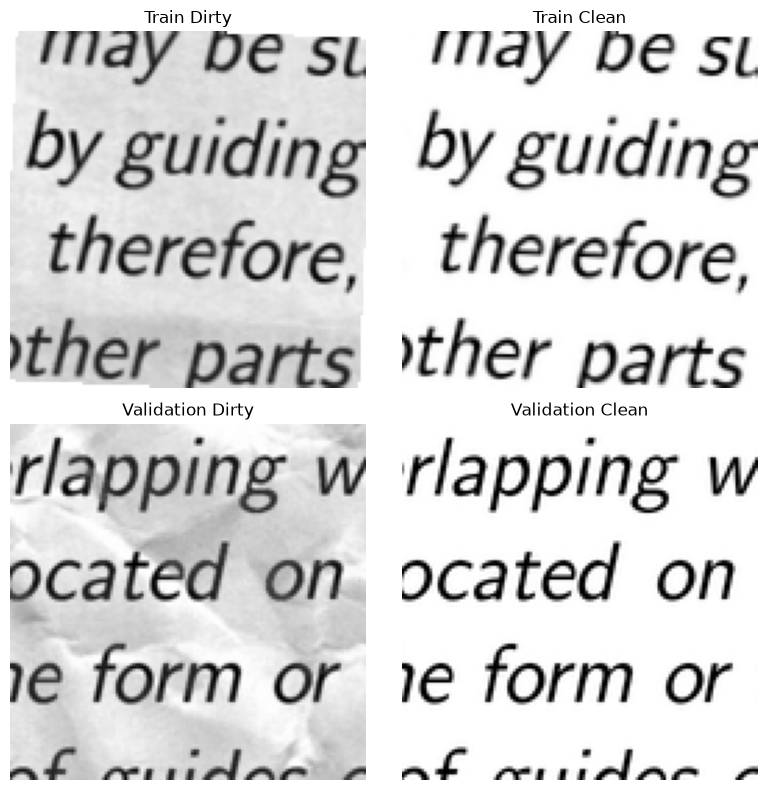

In [53]:
# ------------------------------------------------------------
# 1-7. 학습·검증 이미지 쌍 시각화
# ------------------------------------------------------------

# 학습 데이터 한 쌍
train_dirty, train_clean = train_dataset[0]

# 검증 데이터 한 쌍
val_dirty, val_clean = val_dataset[0]


# 2행 2열의 그래프 생성
fig, axes = plt.subplots(
    2,
    2,
    figsize=(8, 8)
)


# 첫 번째 행: 학습 데이터
axes[0][0].imshow(
    train_dirty.squeeze(),
    cmap="gray"
)
axes[0][0].set_title("Train Dirty")

axes[0][1].imshow(
    train_clean.squeeze(),
    cmap="gray"
)
axes[0][1].set_title("Train Clean")


# 두 번째 행: 검증 데이터
axes[1][0].imshow(
    val_dirty.squeeze(),
    cmap="gray"
)
axes[1][0].set_title("Validation Dirty")

axes[1][1].imshow(
    val_clean.squeeze(),
    cmap="gray"
)
axes[1][1].set_title("Validation Clean")


# 모든 그래프의 좌표 눈금 제거
for ax in axes.flat:
    ax.axis("off")


plt.tight_layout()
plt.show()

### 2. 핵심 실험: CNN 복원 성능 개선

#### 2-1. 기본 CNN Autoencoder

실험 목적:
손상된 문서 이미지를 입력받아 깨끗한 이미지로 복원하는 기본 CNN Autoencoder를 학습합니다.

이후 깊은 CNN, BatchNorm, Skip Connection을 추가한 모델과 성능을 비교하기 위한 기준 모델입니다.

In [54]:
# ------------------------------------------------------------
# 2-1-1. Baseline CNN Autoencoder 구조 정의
# ------------------------------------------------------------

class ConvDenoiser(nn.Module):
    """
    손상된 문서 이미지를 입력받아
    깨끗한 문서 이미지로 복원하는 CNN Autoencoder
    """

    def __init__(self):
        super().__init__()


        # ----------------------------------------------------
        # Encoder
        # 이미지 크기를 줄이면서 특징을 추출
        # ----------------------------------------------------

        self.encoder = nn.Sequential(

            # ------------------------------------------------
            # 첫 번째 합성곱층
            # ------------------------------------------------

            # 입력:  (1, 128, 128)
            # 출력: (32, 64, 64)
            nn.Conv2d(
                in_channels=1,       # 입력 채널: 흑백이므로 1
                out_channels=32,     # 출력 특징 맵 개수: 32
                kernel_size=3,       # 3×3 크기의 필터 사용
                stride=2,            # 필터를 2칸씩 이동
                padding=1            # 이미지 가장자리에 1칸 추가
            ),

            # 음수 값을 0으로 변경하는 활성화 함수
            nn.ReLU(),


            # ------------------------------------------------
            # 두 번째 합성곱층
            # ------------------------------------------------

            # 입력:  (32, 64, 64)
            # 출력: (64, 32, 32)
            nn.Conv2d(
                in_channels=32,      # 이전 층의 출력 채널 수
                out_channels=64,     # 출력 특징 맵 개수: 64
                kernel_size=3,       # 3×3 크기의 필터 사용
                stride=2,            # 높이와 너비를 절반으로 축소
                padding=1            # 가장자리 정보 보존
            ),

            # 비선형 특징을 학습할 수 있도록 ReLU 적용
            nn.ReLU()
        )


        # ----------------------------------------------------
        # Decoder
        # 압축된 특징으로 원래 크기의 이미지를 복원
        # ----------------------------------------------------

        self.decoder = nn.Sequential(

            # ------------------------------------------------
            # 첫 번째 전치 합성곱층
            # ------------------------------------------------

            # 입력:  (64, 32, 32)
            # 출력: (32, 64, 64)
            nn.ConvTranspose2d(
                in_channels=64,      # Encoder의 마지막 출력 채널
                out_channels=32,     # 출력 특징 맵 개수
                kernel_size=4,       # 4×4 크기의 필터 사용
                stride=2,            # 높이와 너비를 2배로 확대
                padding=1            # 출력 크기 조절
            ),

            # 음수 값을 0으로 변경
            nn.ReLU(),


            # ------------------------------------------------
            # 두 번째 전치 합성곱층
            # ------------------------------------------------

            # 입력:  (32, 64, 64)
            # 출력: (1, 128, 128)
            nn.ConvTranspose2d(
                in_channels=32,      # 이전 Decoder 층의 출력 채널
                out_channels=1,      # 흑백 이미지이므로 출력 채널 1
                kernel_size=4,       # 4×4 크기의 필터 사용
                stride=2,            # 높이와 너비를 2배로 확대
                padding=1            # 출력 크기 조절
            ),


            # 정답 이미지의 픽셀값이 0~1 범위이므로
            # 모델의 출력 픽셀값도 0~1 범위로 제한
            nn.Sigmoid()
        )


    def forward(self, x):
        """
        입력 이미지가 모델을 통과하는 순서를 정의합니다.
        """

        # 입력 이미지를 Encoder에 통과시켜 잠재 표현 생성
        z = self.encoder(x)

        # 잠재 표현을 Decoder에 통과시켜 이미지 복원
        restored = self.decoder(z)

        # 복원 이미지 반환
        return restored

In [55]:
# ------------------------------------------------------------
# 2-1-2. Baseline 모델 객체 생성
# ------------------------------------------------------------

# 모델을 실행할 때마다 초기 가중치가 달라지는 것을 줄이기 위해
# 모델 생성 직전에 PyTorch의 난수 기준값을 다시 고정합니다.
torch.manual_seed(RANDOM_SEED)


# ConvDenoiser 클래스를 이용해 실제 모델 객체를 생성합니다.
#
# .to(device)를 사용하여 모델을
# CPU, Apple MPS 또는 NVIDIA CUDA 장치로 이동합니다.
baseline_model = ConvDenoiser().to(device)


# 모델의 Encoder와 Decoder 구조를 출력하여 확인합니다.
print(baseline_model)

ConvDenoiser(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): Sigmoid()
  )
)


In [56]:
# ------------------------------------------------------------
# 2-1-3. Baseline 모델의 입력·출력 크기 확인
# ------------------------------------------------------------


# 학습 DataLoader에서 첫 번째 배치 하나를 가져옵니다.
#
# sample_dirty:
# 모델에 입력할 손상 이미지 배치
#
# sample_clean:
# 모델이 맞혀야 하는 깨끗한 정답 이미지 배치
sample_dirty, sample_clean = next(iter(train_loader))


# 모델은 device에 올라가 있으므로
# 입력 이미지도 같은 device로 이동시킵니다.
sample_dirty = sample_dirty.to(device)


# 손상 이미지 배치를 Baseline 모델에 입력합니다.
#
# 아직 모델을 학습하지 않았기 때문에
# 올바른 복원 결과가 나오는 단계는 아닙니다.
#
# 여기서는 Tensor 크기가 정상적인지만 확인합니다.
sample_restored = baseline_model(sample_dirty)


# 손상 이미지, 정답 이미지, 복원 이미지의 크기 출력
print("입력 이미지 크기:", sample_dirty.shape)
print("정답 이미지 크기:", sample_clean.shape)
print("복원 이미지 크기:", sample_restored.shape)

입력 이미지 크기: torch.Size([16, 1, 128, 128])
정답 이미지 크기: torch.Size([16, 1, 128, 128])
복원 이미지 크기: torch.Size([16, 1, 128, 128])


In [57]:
# ------------------------------------------------------------
# 2-1-4. Baseline 학습을 위한 손실함수 설정
# ------------------------------------------------------------

# 모델이 복원한 이미지와 깨끗한 정답 이미지 사이의
# 평균 제곱 오차(Mean Squared Error)를 계산합니다.
#
# 두 이미지의 픽셀값 차이가 클수록 손실이 커지고,
# 두 이미지가 비슷할수록 손실이 작아집니다.
criterion = nn.MSELoss()


# ------------------------------------------------------------
# 2-1-5. Baseline 모델의 Optimizer 설정
# ------------------------------------------------------------

# Adam Optimizer를 사용하여
# 손실이 감소하는 방향으로 모델의 가중치를 수정합니다.
baseline_optimizer = torch.optim.Adam(
    baseline_model.parameters(),  # 수정할 Baseline 모델의 가중치
    lr=1e-3                       # 학습률: 0.001
)


# ------------------------------------------------------------
# 2-1-6. 학습 반복 횟수와 손실 기록 리스트 설정
# ------------------------------------------------------------

# 전체 학습 데이터를 반복해서 학습할 횟수
EPOCHS = 30


# Epoch별 평균 학습 손실을 저장할 리스트
baseline_train_loss_history = []


# Epoch별 평균 검증 손실을 저장할 리스트
baseline_val_loss_history = []


# ------------------------------------------------------------
# 2-1-7. Baseline 모델 학습 및 검증
# ------------------------------------------------------------

# 전체 학습 데이터를 EPOCHS만큼 반복합니다.
#
# epoch 값은 0부터 시작합니다.
# EPOCHS가 30이면 epoch는 0부터 29까지 변합니다.
for epoch in range(EPOCHS):


    # ========================================================
    # 1. 학습 단계
    # ========================================================

    # 모델을 학습 모드로 설정합니다.
    #
    # train()은 모델을 새로 학습시키는 함수가 아니라
    # 모델의 현재 상태를 학습 모드로 변경하는 함수입니다.
    baseline_model.train()


    # 현재 Epoch에서 발생한 학습 손실의 합계를 저장합니다.
    #
    # 새로운 Epoch가 시작될 때마다 0으로 초기화합니다.
    train_loss_sum = 0.0


    # train_loader에서 손상 이미지와 깨끗한 정답 이미지를
    # 배치 단위로 가져옵니다.
    for dirty, clean in train_loader:

        # 모델과 입력 데이터가 같은 연산 장치에 있어야 하므로
        # Dirty와 Clean 이미지를 device로 이동합니다.
        dirty = dirty.to(device)
        clean = clean.to(device)


        # ----------------------------------------------------
        # 1-1. 이전 기울기 초기화
        # ----------------------------------------------------

        # PyTorch는 기울기를 자동으로 누적합니다.
        #
        # 따라서 새로운 배치를 학습하기 전에
        # 이전 배치에서 계산한 기울기를 제거해야 합니다.
        baseline_optimizer.zero_grad()


        # ----------------------------------------------------
        # 1-2. 순전파
        # ----------------------------------------------------

        # 손상 이미지를 Baseline 모델에 입력하여
        # 복원 이미지를 생성합니다.
        #
        # dirty 모양:
        # (배치 크기, 1, 128, 128)
        #
        # restored 모양:
        # (배치 크기, 1, 128, 128)
        restored = baseline_model(dirty)


        # ----------------------------------------------------
        # 1-3. 학습 손실 계산
        # ----------------------------------------------------

        # 모델이 복원한 이미지와 깨끗한 정답 이미지 사이의
        # 평균 제곱 오차를 계산합니다.
        loss = criterion(restored, clean)


        # ----------------------------------------------------
        # 1-4. 역전파
        # ----------------------------------------------------

        # 계산한 손실을 기준으로
        # 모델의 각 가중치에 대한 기울기를 계산합니다.
        #
        # 이 단계에서는 기울기만 계산하며
        # 가중치는 아직 변경되지 않습니다.
        loss.backward()


        # ----------------------------------------------------
        # 1-5. 가중치 수정
        # ----------------------------------------------------

        # backward()에서 계산된 기울기를 이용하여
        # 모델의 가중치를 실제로 수정합니다.
        baseline_optimizer.step()


        # ----------------------------------------------------
        # 1-6. 배치 손실 누적
        # ----------------------------------------------------

        # loss.item()은 현재 배치의 평균 손실입니다.
        #
        # 평균 손실에 현재 배치의 이미지 수를 곱하여
        # 현재 Epoch의 전체 학습 손실에 누적합니다.
        train_loss_sum += loss.item() * len(dirty)


    # --------------------------------------------------------
    # 1-7. 한 Epoch의 평균 학습 손실 계산
    # --------------------------------------------------------

    # 누적한 전체 학습 손실을
    # 학습 Dataset의 전체 이미지 수로 나눕니다.
    train_loss = train_loss_sum / len(train_dataset)


    # 현재 Epoch의 평균 학습 손실을 리스트에 저장합니다.
    #
    # 나중에 학습 손실 그래프를 그릴 때 사용합니다.
    baseline_train_loss_history.append(train_loss)


    # ========================================================
    # 2. 검증 단계
    # ========================================================

    # 모델을 평가 모드로 설정합니다.
    #
    # 검증 데이터는 모델을 학습시키지 않고
    # 현재 모델의 성능만 확인하는 데 사용합니다.
    baseline_model.eval()


    # 현재 Epoch에서 발생한 검증 손실의 합계를 저장합니다.
    val_loss_sum = 0.0


    # 검증에서는 역전파와 가중치 수정이 필요하지 않습니다.
    #
    # no_grad()를 사용하면 기울기를 계산하거나 저장하지 않으므로
    # 메모리를 덜 사용하고 계산 속도도 빨라집니다.
    with torch.no_grad():

        # val_loader에서 검증 데이터를 배치 단위로 가져옵니다.
        for dirty, clean in val_loader:

            # 검증 데이터도 모델과 같은 연산 장치로 이동합니다.
            dirty = dirty.to(device)
            clean = clean.to(device)


            # ------------------------------------------------
            # 2-1. 검증 순전파
            # ------------------------------------------------

            # 검증 손상 이미지를 Baseline 모델에 입력하여
            # 복원 이미지를 생성합니다.
            restored = baseline_model(dirty)


            # ------------------------------------------------
            # 2-2. 검증 손실 계산
            # ------------------------------------------------

            # 복원 이미지와 깨끗한 검증 정답 이미지 사이의
            # 평균 제곱 오차를 계산합니다.
            loss = criterion(restored, clean)


            # ------------------------------------------------
            # 2-3. 검증 손실 누적
            # ------------------------------------------------

            # 현재 검증 배치의 평균 손실에 이미지 수를 곱하여
            # 전체 검증 손실에 누적합니다.
            val_loss_sum += loss.item() * len(dirty)


    # --------------------------------------------------------
    # 2-4. 한 Epoch의 평균 검증 손실 계산
    # --------------------------------------------------------

    # 누적한 전체 검증 손실을
    # 검증 Dataset의 전체 이미지 수로 나눕니다.
    val_loss = val_loss_sum / len(val_dataset)


    # 현재 Epoch의 평균 검증 손실을 리스트에 저장합니다.
    #
    # 학습 손실과 비교하여 과적합 여부를 확인할 수 있습니다.
    baseline_val_loss_history.append(val_loss)


    # ========================================================
    # 3. 중간 학습 결과 출력
    # ========================================================

    # 출력 결과가 지나치게 길어지는 것을 막기 위해
    # 5 Epoch마다 학습 손실과 검증 손실을 출력합니다.
    if (epoch + 1) % 5 == 0:

        print(
            # Epoch 번호를 정수 세 자리 공간으로 출력
            f"epoch {epoch + 1:3d} | "

            # 평균 학습 손실을 소수점 아래 5자리까지 출력
            f"train loss {train_loss:.5f} | "

            # 평균 검증 손실을 소수점 아래 5자리까지 출력
            f"val loss {val_loss:.5f}"
        )

epoch   5 | train loss 0.06735 | val loss 0.07577
epoch  10 | train loss 0.04406 | val loss 0.04558
epoch  15 | train loss 0.02153 | val loss 0.02537
epoch  20 | train loss 0.01671 | val loss 0.01832
epoch  25 | train loss 0.01163 | val loss 0.01236
epoch  30 | train loss 0.00882 | val loss 0.00937


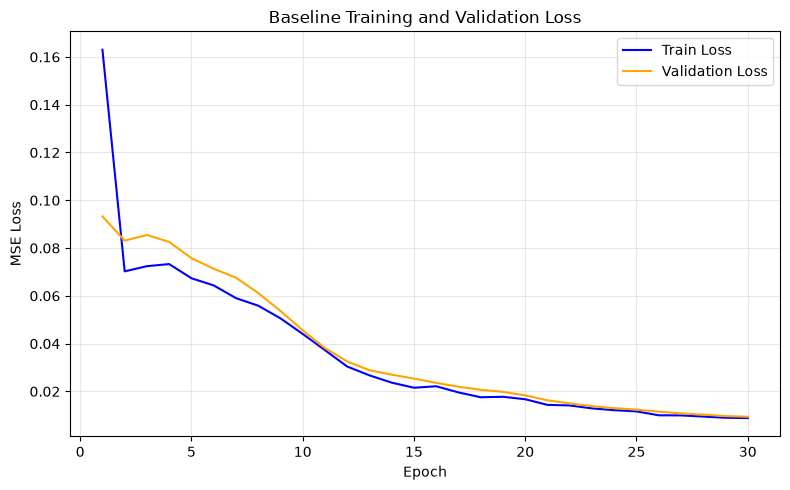

In [58]:
# ------------------------------------------------------------
# 2-1-8. Epoch별 학습·검증 손실 그래프
# ------------------------------------------------------------


# 실제로 저장된 학습 손실 개수를 기준으로
# 그래프의 X축 Epoch 번호를 생성합니다.
#
# 손실이 30개 저장되었다면:
# 1, 2, 3, ..., 30
epochs = range(
    1,
    len(baseline_train_loss_history) + 1
)


# 그래프 전체 크기를 설정합니다.
plt.figure(figsize=(8, 5))


# Epoch별 평균 학습 손실을 선으로 표시합니다.
plt.plot(
    epochs,
    baseline_train_loss_history,
    label="Train Loss",
    color="blue"
)


# Epoch별 평균 검증 손실을 선으로 표시합니다.
plt.plot(
    epochs,
    baseline_val_loss_history,
    label="Validation Loss",
    color="orange"
)


# X축 이름
plt.xlabel("Epoch")


# Y축 이름
plt.ylabel("MSE Loss")


# 그래프 제목
plt.title("Baseline Training and Validation Loss")


# Train Loss와 Validation Loss의 이름 표시
plt.legend()


# 그래프 값을 읽기 쉽도록 격자 표시
plt.grid(
    alpha=0.3
)


# 그래프 요소가 화면 밖으로 잘리지 않도록 간격 정리
plt.tight_layout()


# 그래프 출력
plt.show()

##### 그래프 해석

- 학습 손실 정상적으로 감소 : 약 0.16 → 약 0.009

- 검증 손실 정상적으로 감소 : 약 0.094 → 약 0.009

    -> 뚜렷한 과적합은 보이지 않음


>> But, 그래프 만으로 "이미지가 깨끗하게 복원되었다"고 확정 지을 수는 없음!!
>>
>> 실제 복원 품질은 복원 이미지와 RMSE·PSNR을 추가로 확인

In [59]:
# ------------------------------------------------------------
# 2-1-9. 검증 이미지 복원 결과 생성
# ------------------------------------------------------------


# 모델을 평가 모드로 설정
baseline_model.eval()


# 검증 DataLoader에서 배치 하나 가져오기
val_dirty, val_clean = next(iter(val_loader))


# 손상 이미지와 깨끗한 이미지를 연산 장치로 이동
val_dirty = val_dirty.to(device)
val_clean = val_clean.to(device)


# 검증에서는 기울기를 계산하지 않음
with torch.no_grad():

    # 검증 손상 이미지를 Baseline 모델로 복원
    val_restored = baseline_model(val_dirty)

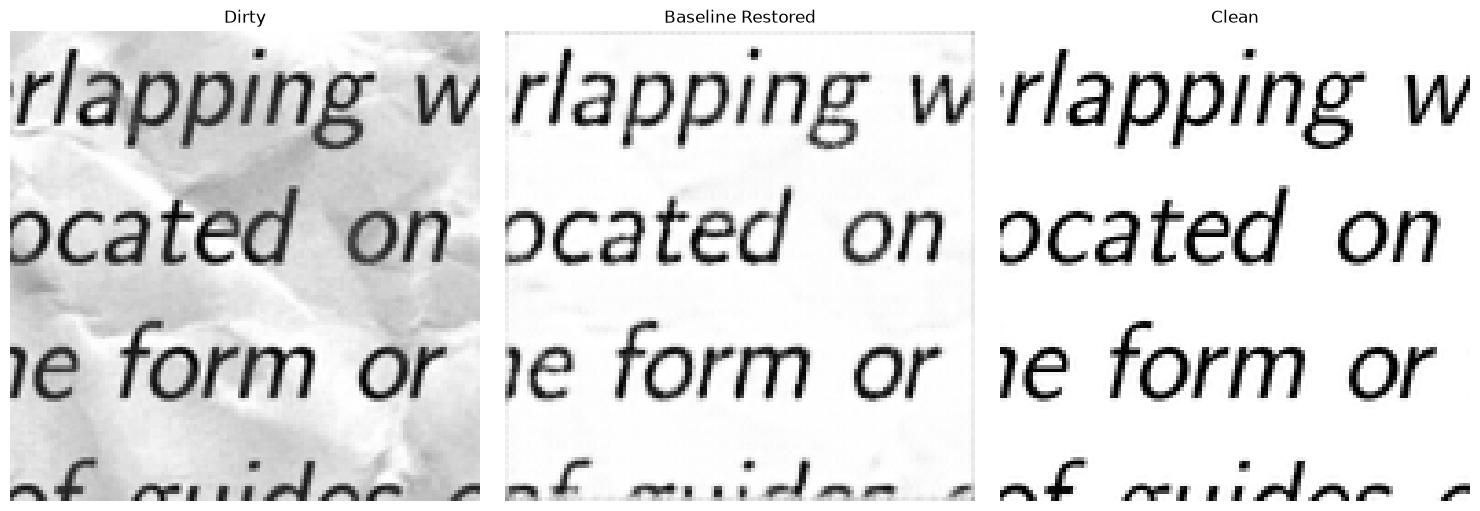

In [60]:
# ------------------------------------------------------------
# 2-1-10. Baseline 복원 결과 시각화
# ------------------------------------------------------------


# 배치 안에서 확인할 이미지 번호
# 0은 현재 검증 배치의 첫 번째 이미지를 의미합니다.
sample_index = 0


# PyTorch Tensor를 Matplotlib에서 출력하기 위해
# 연산 장치에서 CPU로 이동합니다.
dirty_image = val_dirty[sample_index].detach().cpu()
restored_image = val_restored[sample_index].detach().cpu()
clean_image = val_clean[sample_index].detach().cpu()


# Dirty, Restored, Clean 이미지를
# 1행 3열로 나란히 출력합니다.
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)


# ------------------------------------------------------------
# 1. 손상 이미지
# ------------------------------------------------------------

axes[0].imshow(
    dirty_image.squeeze(),
    cmap="gray"
)

axes[0].set_title("Dirty")


# ------------------------------------------------------------
# 2. Baseline 모델의 복원 이미지
# ------------------------------------------------------------

axes[1].imshow(
    restored_image.squeeze(),
    cmap="gray"
)

axes[1].set_title("Baseline Restored")


# ------------------------------------------------------------
# 3. 깨끗한 정답 이미지
# ------------------------------------------------------------

axes[2].imshow(
    clean_image.squeeze(),
    cmap="gray"
)

axes[2].set_title("Clean")


# 세 그래프의 좌표축과 눈금 제거
for ax in axes:
    ax.axis("off")


# 그래프 간격 정리
plt.tight_layout()


# 이미지 출력
plt.show()

In [61]:
# ------------------------------------------------------------
# 2-1-11. RMSE 계산 함수
# ------------------------------------------------------------

def calculate_rmse(restored, clean):
    """
    복원 이미지와 깨끗한 정답 이미지 사이의
    RMSE를 계산합니다.
    """

    # 복원 이미지와 정답 이미지의 평균 제곱 오차
    mse = ((restored - clean) ** 2).mean()


    # MSE에 제곱근을 적용하여 RMSE 계산
    rmse = torch.sqrt(mse)


    # Tensor를 일반 Python 숫자로 변환하여 반환
    return rmse.item()


# ------------------------------------------------------------
# 2-1-12. PSNR 계산 함수
# ------------------------------------------------------------

def calculate_psnr(restored, clean):
    """
    복원 이미지와 깨끗한 정답 이미지 사이의
    PSNR을 계산합니다.
    """

    # 복원 이미지와 정답 이미지의 평균 제곱 오차
    mse = ((restored - clean) ** 2).mean()


    # MSE가 0이면 두 이미지가 완전히 동일함
    if mse.item() == 0:
        return float("inf")


    # 픽셀 최댓값이 1일 때의 PSNR 계산
    psnr = 10 * torch.log10(1.0 / mse)


    # Tensor를 일반 Python 숫자로 변환하여 반환
    return psnr.item()


# ------------------------------------------------------------
# 2-1-13. 전체 검증 데이터의 RMSE·PSNR 계산
# ------------------------------------------------------------

# 모델을 평가 모드로 설정
baseline_model.eval()


# 검증 이미지별 평가 점수를 저장할 리스트
#
# 이 셀을 다시 실행할 때 이전 평가 결과가 중복되지 않도록
# 반드시 빈 리스트로 다시 초기화합니다.
baseline_rmse_values = []
baseline_psnr_values = []


# 검증에서는 기울기를 계산하지 않음
with torch.no_grad():

    # 검증 데이터를 배치 단위로 가져오기
    for dirty, clean in val_loader:

        # 모델과 같은 연산 장치로 이동
        dirty = dirty.to(device)
        clean = clean.to(device)


        # 검증 손상 이미지 복원
        restored = baseline_model(dirty)


        # 현재 배치 안의 이미지를 한 장씩 평가
        for image_index in range(len(dirty)):

            # 현재 이미지의 RMSE 계산
            image_rmse = calculate_rmse(
                restored[image_index],
                clean[image_index]
            )


            # 현재 이미지의 PSNR 계산
            image_psnr = calculate_psnr(
                restored[image_index],
                clean[image_index]
            )


            # 이미지별 평가 결과 저장
            baseline_rmse_values.append(image_rmse)
            baseline_psnr_values.append(image_psnr)

# ------------------------------------------------------------
# 2-1-14. Baseline의 평균 RMSE·PSNR 출력
# ------------------------------------------------------------

# 검증 이미지들의 평균 RMSE
baseline_rmse = np.mean(
    baseline_rmse_values
)


# 검증 이미지들의 평균 PSNR
baseline_psnr = np.mean(
    baseline_psnr_values
)


# 평가 결과 출력
print("평가 이미지 수:", len(baseline_rmse_values))
print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"Baseline PSNR: {baseline_psnr:.2f} dB")

평가 이미지 수: 29
Baseline RMSE: 0.0961
Baseline PSNR: 20.41 dB


In [62]:
# ------------------------------------------------------------
# 2-1-15. 복원 전 Dirty 이미지의 RMSE·PSNR 계산
# ------------------------------------------------------------


# Dirty 이미지별 RMSE를 저장할 리스트
dirty_rmse_values = []


# Dirty 이미지별 PSNR을 저장할 리스트
dirty_psnr_values = []


# 검증 데이터를 배치 단위로 가져오기
for dirty, clean in val_loader:

    # Dirty와 Clean을 같은 연산 장치로 이동
    dirty = dirty.to(device)
    clean = clean.to(device)


    # 현재 배치의 이미지를 한 장씩 평가
    for image_index in range(len(dirty)):

        # 복원 전 Dirty 이미지와 Clean 이미지 사이의 RMSE
        image_rmse = calculate_rmse(
            dirty[image_index],
            clean[image_index]
        )


        # 복원 전 Dirty 이미지와 Clean 이미지 사이의 PSNR
        image_psnr = calculate_psnr(
            dirty[image_index],
            clean[image_index]
        )


        # 계산한 RMSE 저장
        dirty_rmse_values.append(image_rmse)


        # 계산한 PSNR 저장
        dirty_psnr_values.append(image_psnr)


# ------------------------------------------------------------
# 2-1-16. Baseline 복원 전후 성능 비교
# ------------------------------------------------------------


# 복원 전 Dirty 이미지의 평균 RMSE
dirty_rmse = np.mean(
    dirty_rmse_values
)


# 복원 전 Dirty 이미지의 평균 PSNR
dirty_psnr = np.mean(
    dirty_psnr_values
)


# RMSE가 얼마나 감소했는지 계산
# RMSE는 작아질수록 좋으므로 Dirty에서 Baseline을 뺍니다.
rmse_reduction = dirty_rmse - baseline_rmse


# PSNR이 얼마나 증가했는지 계산
# PSNR은 커질수록 좋으므로 Baseline에서 Dirty를 뺍니다.
psnr_gain = baseline_psnr - dirty_psnr


# ------------------------------------------------------------
# 2-1-17. Baseline 복원 전후 성능 출력
# ------------------------------------------------------------

print("평가 이미지 수:", len(dirty_rmse_values))

print()


# 복원 전 Dirty 이미지의 성능
print("[복원 전 Dirty 이미지]")
print(f"RMSE: {dirty_rmse:.4f}")
print(f"PSNR: {dirty_psnr:.2f} dB")

print()


# Baseline 모델로 복원한 이미지의 성능
print("[Baseline 복원 이미지]")
print(f"RMSE: {baseline_rmse:.4f}")
print(f"PSNR: {baseline_psnr:.2f} dB")

print()


# 복원 전후 개선량
print("[Baseline 개선량]")
print(f"RMSE 감소: {rmse_reduction:.4f}")
print(f"PSNR 증가: {psnr_gain:+.2f} dB")

평가 이미지 수: 29

[복원 전 Dirty 이미지]
RMSE: 0.1449
PSNR: 16.89 dB

[Baseline 복원 이미지]
RMSE: 0.0961
PSNR: 20.41 dB

[Baseline 개선량]
RMSE 감소: 0.0489
PSNR 증가: +3.52 dB


In [63]:
# ------------------------------------------------------------
# 2-1-18. Baseline 실험 결과 저장
# ------------------------------------------------------------

experiment_results = [
    {
        "model": "Dirty Before Restoration",
        "rmse": dirty_rmse,
        "psnr": dirty_psnr
    },
    {
        "model": "Baseline CNN Autoencoder",
        "rmse": baseline_rmse,
        "psnr": baseline_psnr
    }
]


# 저장 결과 확인
for result in experiment_results:
    print(
        result["model"],
        f"| RMSE: {result['rmse']:.4f}",
        f"| PSNR: {result['psnr']:.2f} dB"
    )

Dirty Before Restoration | RMSE: 0.1449 | PSNR: 16.89 dB
Baseline CNN Autoencoder | RMSE: 0.0961 | PSNR: 20.41 dB


"손상 이미지를 Baseline 모델에 통과시키자 실제로 깨끗한 정답에 가까워졌는가?"

>> Baseline CNN Autoencoder를 적용한 결과, 검증 데이터의 평균 RMSE는 0.1449에서 0.0949로 약 34.5% 감소했고, 평균 PSNR은 16.89 dB에서 20.52 dB로 3.64 dB 증가했다. 
>>
>> 따라서 Baseline 모델이 손상된 문서 이미지의 배경 잡음을 제거하고 깨끗한 정답 이미지에 더 가까운 결과를 생성했음을 확인했다. 
>>
>>다만 복원 이미지의 글자 경계가 다소 흐려지는 한계가 관찰됐다.

#### 2-2. 깊은 CNN + BatchNorm

In [64]:
# ------------------------------------------------------------
# 2-2-1. 깊은 CNN + BatchNorm 모델 구조 정의
# ------------------------------------------------------------

class DeepConvDenoiser(nn.Module):

    def __init__(self):
        super().__init__()


        # ====================================================
        # Encoder
        # ====================================================

        self.encoder = nn.Sequential(

            # 첫 번째 합성곱층
            # (1, 128, 128) → (32, 64, 64)
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                stride=2,
                padding=1
            ),
            # 앞의 Conv2d가 출력한 채널 수를 정규화
            nn.BatchNorm2d(32),
            # 비선형 활성화 함수
            nn.ReLU(),


            # 두 번째 합성곱층
            # (32, 64, 64) → (64, 32, 32)
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                stride=2,
                padding=1
            ),
            # 두 번째 Conv2d의 출력 채널 정규화
            nn.BatchNorm2d(64),
            nn.ReLU(),


            # 세 번째 합성곱층
            # (64, 32, 32) → (128, 16, 16)
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                stride=2,
                padding=1
            ),
            # 세 번째 Conv2d의 출력 채널 정규화
            nn.BatchNorm2d(128),
            nn.ReLU(),

            # 네 번째 합성곱층
            # (128, 16, 16) → (256, 8, 8)
            nn.Conv2d(
                in_channels=128,
                out_channels=256,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            # 네 번째 Conv2d의 출력 채널 정규화
            nn.BatchNorm2d(256),

            nn.ReLU()
        )


        # ====================================================
        # Decoder
        # ====================================================

        self.decoder = nn.Sequential(

            # 첫 번째 전치 합성곱층
            # (256, 8, 8) → (128, 16, 16)
            nn.ConvTranspose2d(
                in_channels=256,
                out_channels=128,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            # 첫 번째 Decoder 출력 채널 정규화
            nn.BatchNorm2d(128),
            nn.ReLU(),


            # 두 번째 전치 합성곱층
            # (128, 16, 16) → (64, 32, 32)
            nn.ConvTranspose2d(
                in_channels=128,
                out_channels=64,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            # 두 번째 Decoder 출력 채널 정규화
            nn.BatchNorm2d(64),
            nn.ReLU(),


            # 세 번째 전치 합성곱층
            # (64, 32, 32) → (32, 64, 64)
            nn.ConvTranspose2d(
                in_channels=64,
                out_channels=32,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            # 세 번째 Decoder 출력 채널 정규화
            nn.BatchNorm2d(32),
            nn.ReLU(),


            # 마지막 전치 합성곱층
            # (32, 64, 64) → (1, 128, 128)
            nn.ConvTranspose2d(
                in_channels=32,
                out_channels=1,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            # 출력 픽셀값을 0~1 범위로 제한
            nn.Sigmoid()
        )

    def forward(self, x):
        """
        손상 이미지를 Encoder와 Decoder에 차례대로 통과시켜
        복원 이미지를 반환합니다.
        """

        # 손상 이미지에서 깊은 잠재 표현 추출
        z = self.encoder(x)


        # 잠재 표현으로 이미지 복원
        restored = self.decoder(z)


        # 복원 이미지 반환
        return restored

In [65]:
# ------------------------------------------------------------
# 2-2-2. 깊은 CNN + BatchNorm 모델 생성
# ------------------------------------------------------------

# 모델의 초기 가중치 생성을 재현할 수 있도록 난수 고정
torch.manual_seed(RANDOM_SEED)


# 깊은 CNN 모델 객체를 생성하고 연산 장치로 이동
deep_model = DeepConvDenoiser().to(device)


# 모델 구조 출력
print(deep_model)

DeepConvDenoiser(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=Tru

In [66]:
# ------------------------------------------------------------
# 2-2-3. 깊은 CNN 모델의 입출력 크기 확인
# ------------------------------------------------------------


# 학습 DataLoader에서 배치 하나 가져오기
deep_sample_dirty, deep_sample_clean = next(iter(train_loader))


# 손상 이미지를 모델과 같은 연산 장치로 이동
deep_sample_dirty = deep_sample_dirty.to(device)


# BatchNorm의 통계가 크기 확인 과정에서 변경되지 않도록
# 모델을 평가 모드로 설정
deep_model.eval()


# 기울기를 계산하지 않고 입출력 크기만 확인
with torch.no_grad():

    # 깊은 CNN 모델로 이미지 복원
    deep_sample_restored = deep_model(deep_sample_dirty)


# 입력, 정답, 복원 이미지 크기 출력
print("입력 이미지 크기:", deep_sample_dirty.shape)
print("정답 이미지 크기:", deep_sample_clean.shape)
print("복원 이미지 크기:", deep_sample_restored.shape)

입력 이미지 크기: torch.Size([16, 1, 128, 128])
정답 이미지 크기: torch.Size([16, 1, 128, 128])
복원 이미지 크기: torch.Size([16, 1, 128, 128])


In [67]:
# ------------------------------------------------------------
# 2-2-4. 깊은 CNN 모델의 학습 설정
# ------------------------------------------------------------


# 복원 이미지와 정답 이미지 사이의 MSE 계산
deep_criterion = nn.MSELoss()


# 깊은 CNN 모델의 가중치를 수정할 Adam Optimizer
deep_optimizer = torch.optim.Adam(
    deep_model.parameters(),
    lr=1e-3
)


# Baseline과 동일한 Epoch 수 사용
DEEP_EPOCHS = 30


# Epoch별 학습 손실을 저장할 리스트
deep_train_loss_history = []


# Epoch별 검증 손실을 저장할 리스트
deep_val_loss_history = []

In [68]:
# ------------------------------------------------------------
# 2-2-5. 깊은 CNN + BatchNorm 모델 학습 및 검증
# ------------------------------------------------------------

for epoch in range(DEEP_EPOCHS):


    # ========================================================
    # 1. 학습
    # ========================================================

    # BatchNorm이 현재 배치의 통계를 사용하도록 학습 모드 설정
    deep_model.train()


    # 현재 Epoch의 학습 손실 누적값
    train_loss_sum = 0.0


    # 학습 데이터를 배치 단위로 가져오기
    for dirty, clean in train_loader:

        # 모델과 같은 연산 장치로 이동
        dirty = dirty.to(device)
        clean = clean.to(device)


        # 이전 배치에서 계산한 기울기 제거
        deep_optimizer.zero_grad()


        # 손상 이미지를 깊은 CNN 모델로 복원
        restored = deep_model(dirty)


        # 복원 이미지와 깨끗한 정답 사이의 MSE 계산
        loss = deep_criterion(restored, clean)


        # 기울기 계산
        loss.backward()


        # 깊은 CNN 모델의 가중치 수정
        deep_optimizer.step()


        # 현재 배치의 손실 누적
        train_loss_sum += loss.item() * len(dirty)


    # 현재 Epoch의 평균 학습 손실
    train_loss = train_loss_sum / len(train_dataset)


    # 학습 손실 기록
    deep_train_loss_history.append(train_loss)


    # ========================================================
    # 2. 검증
    # ========================================================

    # BatchNorm이 학습 중 저장한 통계를 사용하도록 평가 모드 설정
    deep_model.eval()


    # 현재 Epoch의 검증 손실 누적값
    val_loss_sum = 0.0


    # 검증에서는 기울기를 계산하지 않음
    with torch.no_grad():

        # 검증 데이터를 배치 단위로 가져오기
        for dirty, clean in val_loader:

            dirty = dirty.to(device)
            clean = clean.to(device)


            # 검증 이미지 복원
            restored = deep_model(dirty)


            # 검증 MSE 계산
            loss = deep_criterion(restored, clean)


            # 검증 손실 누적
            val_loss_sum += loss.item() * len(dirty)


    # 현재 Epoch의 평균 검증 손실
    val_loss = val_loss_sum / len(val_dataset)


    # 검증 손실 기록
    deep_val_loss_history.append(val_loss)


    # ========================================================
    # 3. 중간 결과 출력
    # ========================================================

    # 5 Epoch마다 결과 출력
    if (epoch + 1) % 5 == 0:

        print(
            f"epoch {epoch + 1:3d} | "
            f"train loss {train_loss:.5f} | "
            f"val loss {val_loss:.5f}"
        )

epoch   5 | train loss 0.06100 | val loss 0.06809
epoch  10 | train loss 0.04720 | val loss 0.05948
epoch  15 | train loss 0.03713 | val loss 0.04790
epoch  20 | train loss 0.02696 | val loss 0.03336
epoch  25 | train loss 0.02127 | val loss 0.02689
epoch  30 | train loss 0.01814 | val loss 0.02190


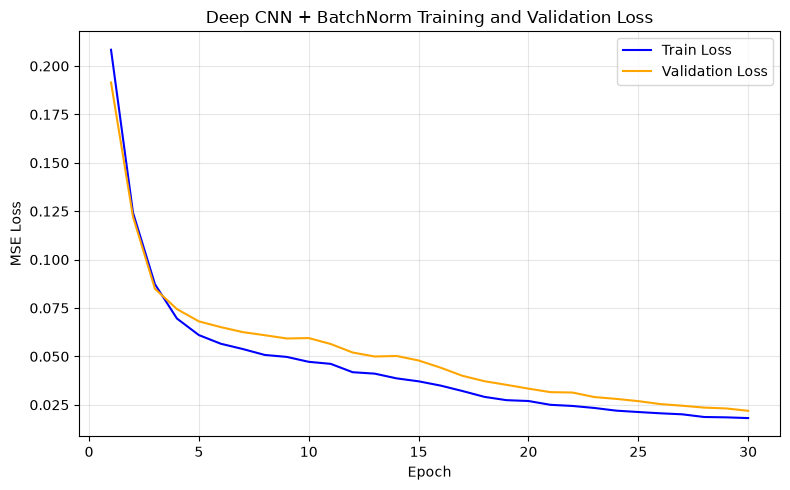

In [69]:
# ------------------------------------------------------------
# 2-2-6. 깊은 CNN의 학습·검증 손실 그래프
# ------------------------------------------------------------

# 실제 저장된 손실 개수를 기준으로 Epoch 번호 생성
epochs = range(
    1,
    len(deep_train_loss_history) + 1
)


plt.figure(figsize=(8, 5))


# 학습 손실
plt.plot(
    epochs,
    deep_train_loss_history,
    label="Train Loss",
    color="blue"
)


# 검증 손실
plt.plot(
    epochs,
    deep_val_loss_history,
    label="Validation Loss",
    color="orange"
)


plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Deep CNN + BatchNorm Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

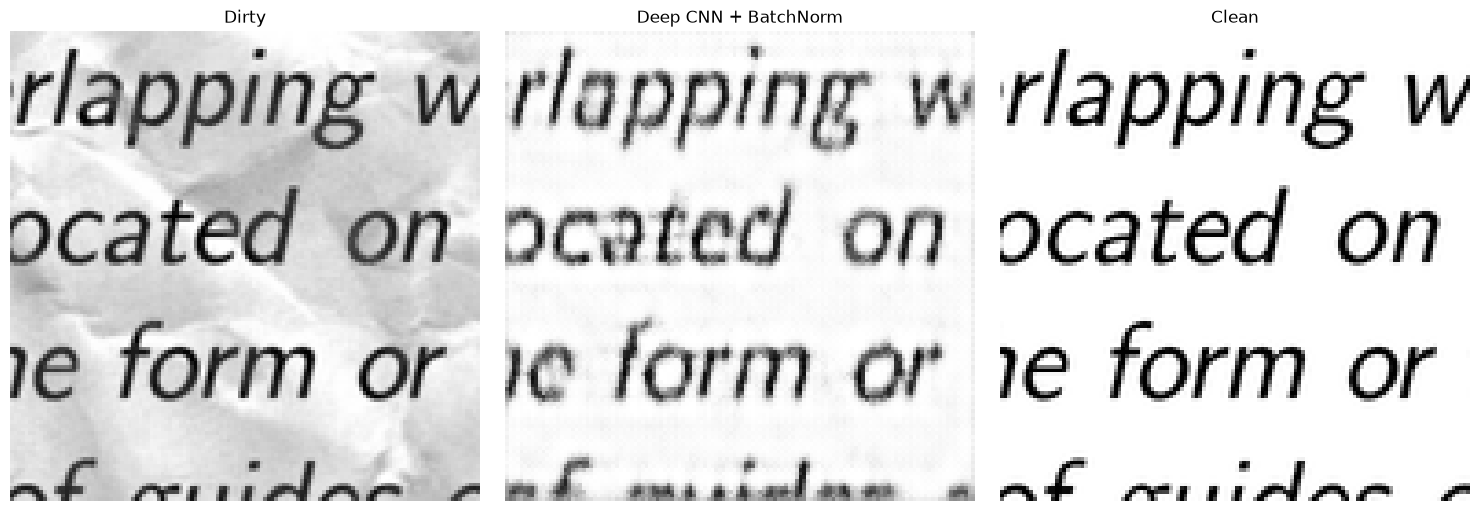

In [70]:
# ------------------------------------------------------------
# 2-2-7. 깊은 CNN의 검증 이미지 복원 결과 확인
# ------------------------------------------------------------

# 모델을 평가 모드로 설정
deep_model.eval()


# 검증 데이터에서 배치 하나 가져오기
deep_val_dirty, deep_val_clean = next(iter(val_loader))


# 모델과 같은 연산 장치로 이동
deep_val_dirty = deep_val_dirty.to(device)
deep_val_clean = deep_val_clean.to(device)


# 깊은 CNN 모델로 복원
with torch.no_grad():

    deep_val_restored = deep_model(deep_val_dirty)


# 확인할 이미지 번호
sample_index = 0


# Matplotlib 출력을 위해 CPU로 이동
dirty_image = deep_val_dirty[sample_index].detach().cpu()
restored_image = deep_val_restored[sample_index].detach().cpu()
clean_image = deep_val_clean[sample_index].detach().cpu()


# 복원 전, 복원 후, 정답 이미지 출력
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)


axes[0].imshow(
    dirty_image.squeeze(),
    cmap="gray"
)
axes[0].set_title("Dirty")


axes[1].imshow(
    restored_image.squeeze(),
    cmap="gray"
)
axes[1].set_title("Deep CNN + BatchNorm")


axes[2].imshow(
    clean_image.squeeze(),
    cmap="gray"
)
axes[2].set_title("Clean")


for ax in axes:
    ax.axis("off")


plt.tight_layout()
plt.show()

In [71]:
# ------------------------------------------------------------
# 2-2-8. 깊은 CNN의 전체 검증 데이터 평가
# ------------------------------------------------------------

# 모델을 평가 모드로 설정
deep_model.eval()


# 이미지별 평가 결과를 저장할 리스트
#
# 셀을 다시 실행할 때 결과가 중복되지 않도록
# 반드시 빈 리스트로 초기화합니다.
deep_rmse_values = []
deep_psnr_values = []


with torch.no_grad():

    # 전체 검증 데이터 반복
    for dirty, clean in val_loader:

        dirty = dirty.to(device)
        clean = clean.to(device)


        # 깊은 CNN 모델로 이미지 복원
        restored = deep_model(dirty)


        # 현재 배치의 이미지를 한 장씩 평가
        for image_index in range(len(dirty)):

            image_rmse = calculate_rmse(
                restored[image_index],
                clean[image_index]
            )

            image_psnr = calculate_psnr(
                restored[image_index],
                clean[image_index]
            )

            deep_rmse_values.append(image_rmse)
            deep_psnr_values.append(image_psnr)


# 검증 이미지들의 평균 RMSE·PSNR
deep_rmse = np.mean(deep_rmse_values)
deep_psnr = np.mean(deep_psnr_values)


print("평가 이미지 수:", len(deep_rmse_values))
print(f"Deep CNN RMSE: {deep_rmse:.4f}")
print(f"Deep CNN PSNR: {deep_psnr:.2f} dB")

평가 이미지 수: 29
Deep CNN RMSE: 0.1474
Deep CNN PSNR: 16.67 dB


In [72]:
# ------------------------------------------------------------
# 2-2-9. Baseline과 깊은 CNN 성능 비교
# ------------------------------------------------------------

# RMSE는 작을수록 좋음
#
# 양수: 깊은 CNN의 RMSE가 감소함
# 음수: 깊은 CNN의 RMSE가 증가함
rmse_improvement = baseline_rmse - deep_rmse


# PSNR은 클수록 좋음
#
# 양수: 깊은 CNN의 PSNR이 증가함
# 음수: 깊은 CNN의 PSNR이 감소함
psnr_improvement = deep_psnr - baseline_psnr


print("[Baseline CNN Autoencoder]")
print(f"RMSE: {baseline_rmse:.4f}")
print(f"PSNR: {baseline_psnr:.2f} dB")

print()

print("[Deep CNN + BatchNorm]")
print(f"RMSE: {deep_rmse:.4f}")
print(f"PSNR: {deep_psnr:.2f} dB")

print()

print("[Baseline 대비 성능 변화]")
print(f"RMSE 개선: {rmse_improvement:+.4f}")
print(f"PSNR 개선: {psnr_improvement:+.2f} dB")

[Baseline CNN Autoencoder]
RMSE: 0.0961
PSNR: 20.41 dB

[Deep CNN + BatchNorm]
RMSE: 0.1474
PSNR: 16.67 dB

[Baseline 대비 성능 변화]
RMSE 개선: -0.0513
PSNR 개선: -3.74 dB


In [73]:
# ------------------------------------------------------------
# 2-2-10. 깊은 CNN 실험 결과 저장
# ------------------------------------------------------------

experiment_results.append(
    {
        "model": "Deep CNN + BatchNorm",
        "rmse": deep_rmse,
        "psnr": deep_psnr
    }
)


# 지금까지 저장한 실험 결과 확인
for result in experiment_results:

    print(
        result["model"],
        f"| RMSE: {result['rmse']:.4f}",
        f"| PSNR: {result['psnr']:.2f} dB"
    )

Dirty Before Restoration | RMSE: 0.1449 | PSNR: 16.89 dB
Baseline CNN Autoencoder | RMSE: 0.0961 | PSNR: 20.41 dB
Deep CNN + BatchNorm | RMSE: 0.1474 | PSNR: 16.67 dB


##### 성능이 낮아진 원인
1. 이미지를 너무 많이 축소함

2. Skip Connection이 없음

3. 30 Epoch에서 아직 충분히 수렴하지 않음

>>Epoch 20: val loss 0.03321
>> 
>> Epoch 25: val loss 0.02689
>>
>> Epoch 30: val loss 0.02157

##### 현재 결과를 그대로 유지 : Skip Connection 실험 진행

-  실패한 실험이 아니라 다음 가설을 확인한 결과

-  모델을 단순히 깊게 만들고 BatchNorm을 추가하는 것만으로는 문서 복원 성능이 향상되지 않았다. 

-  네 번의 다운샘플링으로 글자의 세부 정보가 손실됐고, 이를 전달할 별도의 경로가 없어 Baseline보다 복원 성능이 낮아진 것으로 판단된다.


##### 추가 Epoch는 튜닝 단계에서 실험

- 현재 깊은 모델만 바로 60 Epoch로 바꾸기보다는, 일단 동일한 30 Epoch 조건의 결과를 기록하는 것이 더 공정

##### 정리

>> 깊은 CNN과 BatchNorm을 적용한 모델은 평균 RMSE 0.1462, PSNR 16.74 dB를 기록하여 Baseline의 RMSE 0.0949, PSNR 20.52 dB보다 낮은 성능을 보였다. 
>> 
>> 학습 및 검증 손실은 지속해서 감소했으므로 뚜렷한 과적합은 관찰되지 않았지만, 입력을 8×8 크기까지 축소하는 과정에서 문서 글자의 세부 정보가 손실된 것으로 판단된다. 
>>
>> 이에 따라 다음 실험에서는 Encoder의 중간 특징을 Decoder로 전달하는 Skip Connection을 추가하여 세부 정보 보존 효과를 확인한다.

#### 2-3. 깊은 CNN + BatchNorm + Skip Connection

In [74]:
# ------------------------------------------------------------
# 2-3-1. 깊은 CNN + BatchNorm + Skip Connection 모델 정의
# ------------------------------------------------------------

class SkipConvDenoiser(nn.Module):
    """
    깊은 CNN과 BatchNorm 구조에 Skip Connection을 추가한 모델입니다.

    Encoder의 중간 특징을 Decoder로 직접 전달하여
    다운샘플링 과정에서 손실될 수 있는 글자와 윤곽 정보를 보존합니다.
    """

    def __init__(self):
        super().__init__()


        # ====================================================
        # Encoder 1
        # ====================================================

        # 입력:  (1, 128, 128)
        # 출력: (32, 64, 64)
        self.encoder1 = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )


        # ====================================================
        # Encoder 2
        # ====================================================

        # 입력:  (32, 64, 64)
        # 출력: (64, 32, 32)
        self.encoder2 = nn.Sequential(
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )


        # ====================================================
        # Encoder 3
        # ====================================================

        # 입력:  (64, 32, 32)
        # 출력: (128, 16, 16)
        self.encoder3 = nn.Sequential(
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )


        # ====================================================
        # Encoder 4: 가장 압축된 잠재 표현
        # ====================================================

        # 입력:  (128, 16, 16)
        # 출력: (256, 8, 8)
        self.encoder4 = nn.Sequential(
            nn.Conv2d(
                in_channels=128,
                out_channels=256,
                kernel_size=3,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )


        # ====================================================
        # Decoder 1
        # ====================================================

        # 입력:  (256, 8, 8)
        # 출력: (128, 16, 16)
        self.decoder1 = nn.Sequential(
            nn.ConvTranspose2d(
                in_channels=256,
                out_channels=128,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )


        # ====================================================
        # Decoder 2
        # ====================================================

        # decoder1과 encoder3을 연결하면:
        # 128 + 128 = 256채널
        #
        # 입력:  (256, 16, 16)
        # 출력: (64, 32, 32)
        self.decoder2 = nn.Sequential(
            nn.ConvTranspose2d(
                in_channels=256,
                out_channels=64,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )


        # ====================================================
        # Decoder 3
        # ====================================================

        # decoder2와 encoder2를 연결하면:
        # 64 + 64 = 128채널
        #
        # 입력:  (128, 32, 32)
        # 출력: (32, 64, 64)
        self.decoder3 = nn.Sequential(
            nn.ConvTranspose2d(
                in_channels=128,
                out_channels=32,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )


        # ====================================================
        # 최종 출력층
        # ====================================================

        # decoder3과 encoder1을 연결하면:
        # 32 + 32 = 64채널
        #
        # 입력:  (64, 64, 64)
        # 출력: (1, 128, 128)
        self.output_layer = nn.Sequential(
            nn.ConvTranspose2d(
                in_channels=64,
                out_channels=1,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.Sigmoid()
        )


    def forward(self, x):
        """
        Encoder의 중간 출력을 저장한 뒤,
        대응하는 Decoder 출력과 채널 방향으로 연결합니다.
        """

        # ====================================================
        # Encoder
        # ====================================================

        # (배치, 1, 128, 128)
        # → (배치, 32, 64, 64)
        e1 = self.encoder1(x)

        # → (배치, 64, 32, 32)
        e2 = self.encoder2(e1)

        # → (배치, 128, 16, 16)
        e3 = self.encoder3(e2)

        # → (배치, 256, 8, 8)
        z = self.encoder4(e3)


        # ====================================================
        # Decoder + Skip Connection
        # ====================================================

        # (256, 8, 8) → (128, 16, 16)
        d1 = self.decoder1(z)

        # d1과 e3을 채널 방향으로 연결
        # (128 + 128, 16, 16) → (256, 16, 16)
        d1 = torch.cat([d1, e3], dim=1)


        # (256, 16, 16) → (64, 32, 32)
        d2 = self.decoder2(d1)

        # 강사님이 알려주신 torch.cat 방식
        # (64 + 64, 32, 32) → (128, 32, 32)
        d2 = torch.cat([d2, e2], dim=1)


        # (128, 32, 32) → (32, 64, 64)
        d3 = self.decoder3(d2)

        # 세밀한 글자와 윤곽 정보를 전달
        # (32 + 32, 64, 64) → (64, 64, 64)
        d3 = torch.cat([d3, e1], dim=1)


        # (64, 64, 64) → (1, 128, 128)
        restored = self.output_layer(d3)

        return restored

In [75]:
# ------------------------------------------------------------
# 2-3-2. Skip Connection 모델 생성
# ------------------------------------------------------------

# 모델의 초기 가중치를 재현할 수 있도록 난수 고정
torch.manual_seed(RANDOM_SEED)


# 깊은 CNN + BatchNorm + Skip Connection 모델 생성
# 생성한 모델을 CUDA, MPS 또는 CPU로 이동
skip_model = SkipConvDenoiser().to(device)


# 모델 구조 출력
print(skip_model)

SkipConvDenoiser(
  (encoder1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
  )
  (encoder2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
  )
  (encoder3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
  )
  (encoder4): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
  )
  (decoder1): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2)

In [76]:
# ------------------------------------------------------------
# 2-3-3. Skip Connection 모델의 입출력 크기 확인
# ------------------------------------------------------------


# 학습 DataLoader에서 배치 하나 가져오기
skip_sample_dirty, skip_sample_clean = next(iter(train_loader))


# 손상 이미지를 모델과 같은 연산 장치로 이동
skip_sample_dirty = skip_sample_dirty.to(device)


# BatchNorm의 통계가 크기 확인 과정에서 변경되지 않도록
# 모델을 평가 모드로 설정
skip_model.eval()


# 기울기를 계산하지 않고 입출력 크기만 확인
with torch.no_grad():

    # Skip Connection 모델로 이미지 복원
    skip_sample_restored = skip_model(skip_sample_dirty)


# 입력, 정답, 복원 이미지 크기 출력
print("입력 이미지 크기:", skip_sample_dirty.shape)
print("정답 이미지 크기:", skip_sample_clean.shape)
print("복원 이미지 크기:", skip_sample_restored.shape)

입력 이미지 크기: torch.Size([16, 1, 128, 128])
정답 이미지 크기: torch.Size([16, 1, 128, 128])
복원 이미지 크기: torch.Size([16, 1, 128, 128])


In [77]:
# ------------------------------------------------------------
# 2-3-4. Skip Connection 모델의 학습 설정
# ------------------------------------------------------------


# 복원 이미지와 Clean 이미지 사이의 MSE 계산
skip_criterion = nn.MSELoss()


# Skip Connection 모델의 가중치를 수정할 Adam Optimizer
skip_optimizer = torch.optim.Adam(
    skip_model.parameters(),
    lr=1e-3
)


# 다른 모델과 동일한 Epoch 수 사용
SKIP_EPOCHS = 30


# Epoch별 학습 손실을 저장할 리스트
skip_train_loss_history = []


# Epoch별 검증 손실을 저장할 리스트
skip_val_loss_history = []

In [78]:
# ------------------------------------------------------------
# 2-3-5. Skip Connection 모델 학습 및 검증
# ------------------------------------------------------------


# 학습 과정에서 사용하는 난수 기준값 재설정
# 무작위 Crop, 회전, 좌우 반전 등의 재현성을 높이기 위함
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


for epoch in range(SKIP_EPOCHS):


    # ========================================================
    # 1. 학습 단계
    # ========================================================

    # BatchNorm이 현재 학습 배치의 평균과 분산을 사용하도록 설정
    skip_model.train()


    # 현재 Epoch의 학습 손실 누적값
    train_loss_sum = 0.0


    # 학습 데이터를 배치 단위로 가져오기
    for dirty, clean in train_loader:

        # 모델과 같은 연산 장치로 이동
        dirty = dirty.to(device)
        clean = clean.to(device)


        # 이전 배치에서 계산된 기울기 제거
        skip_optimizer.zero_grad()


        # 손상 이미지를 Skip Connection 모델로 복원
        restored = skip_model(dirty)


        # 복원 이미지와 Clean 정답 사이의 MSE 계산
        loss = skip_criterion(
            restored,
            clean
        )


        # 손실을 기준으로 각 가중치의 기울기 계산
        loss.backward()


        # 계산된 기울기를 사용해 모델의 가중치 수정
        skip_optimizer.step()


        # 현재 배치의 손실을 Epoch 손실에 누적
        #
        # loss.item()은 현재 배치의 평균 손실이므로
        # 현재 배치의 이미지 수를 곱해서 누적
        train_loss_sum += loss.item() * len(dirty)


    # 전체 학습 이미지의 평균 손실 계산
    train_loss = train_loss_sum / len(train_dataset)


    # 현재 Epoch의 학습 손실 저장
    skip_train_loss_history.append(train_loss)


    # ========================================================
    # 2. 검증 단계
    # ========================================================

    # BatchNorm이 학습 중 저장한 평균과 분산을 사용하도록 설정
    skip_model.eval()


    # 현재 Epoch의 검증 손실 누적값
    val_loss_sum = 0.0


    # 검증에서는 기울기 계산과 가중치 수정이 필요하지 않음
    with torch.no_grad():

        # 검증 데이터를 배치 단위로 가져오기
        for dirty, clean in val_loader:

            # 모델과 같은 연산 장치로 이동
            dirty = dirty.to(device)
            clean = clean.to(device)


            # 검증 Dirty 이미지 복원
            restored = skip_model(dirty)


            # 복원 이미지와 검증 Clean 이미지 사이의 MSE 계산
            loss = skip_criterion(
                restored,
                clean
            )


            # 현재 검증 배치의 손실 누적
            val_loss_sum += loss.item() * len(dirty)


    # 전체 검증 이미지의 평균 손실 계산
    val_loss = val_loss_sum / len(val_dataset)


    # 현재 Epoch의 검증 손실 저장
    skip_val_loss_history.append(val_loss)


    # ========================================================
    # 3. 중간 결과 출력
    # ========================================================

    # 5 Epoch마다 학습·검증 손실 출력
    if (epoch + 1) % 5 == 0:

        print(
            f"epoch {epoch + 1:3d} | "
            f"train loss {train_loss:.5f} | "
            f"val loss {val_loss:.5f}"
        )

epoch   5 | train loss 0.01638 | val loss 0.02548
epoch  10 | train loss 0.00697 | val loss 0.00656
epoch  15 | train loss 0.00472 | val loss 0.00445
epoch  20 | train loss 0.00400 | val loss 0.00349
epoch  25 | train loss 0.00368 | val loss 0.00290
epoch  30 | train loss 0.00306 | val loss 0.00258


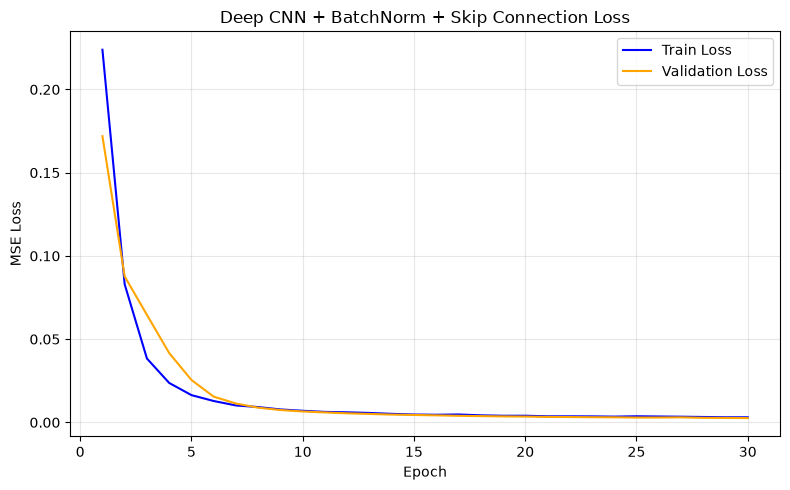

In [79]:
# ------------------------------------------------------------
# 2-3-6. Skip Connection 모델의 학습·검증 손실 그래프
# ------------------------------------------------------------


# 실제로 저장된 손실 개수를 기준으로 Epoch 번호 생성
epochs = range(
    1,
    len(skip_train_loss_history) + 1
)


# 그래프 크기 설정
plt.figure(figsize=(8, 5))


# Epoch별 학습 손실
plt.plot(
    epochs,
    skip_train_loss_history,
    label="Train Loss",
    color="blue"
)


# Epoch별 검증 손실
plt.plot(
    epochs,
    skip_val_loss_history,
    label="Validation Loss",
    color="orange"
)


# 그래프 설명
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Deep CNN + BatchNorm + Skip Connection Loss")


# 각 선의 이름 표시
plt.legend()


# 값을 확인하기 쉽도록 격자 표시
plt.grid(alpha=0.3)


# 그래프 요소가 잘리지 않도록 간격 정리
plt.tight_layout()


# 그래프 출력
plt.show()

In [80]:
# ------------------------------------------------------------
# 2-3-7. Skip Connection 모델의 검증 이미지 복원
# ------------------------------------------------------------


# 모델을 평가 모드로 설정
skip_model.eval()


# 검증 DataLoader에서 배치 하나 가져오기
skip_val_dirty, skip_val_clean = next(iter(val_loader))


# 모델과 같은 연산 장치로 이동
skip_val_dirty = skip_val_dirty.to(device)
skip_val_clean = skip_val_clean.to(device)


# 검증에서는 기울기를 계산하지 않음
with torch.no_grad():

    # 검증 Dirty 이미지를 Skip Connection 모델로 복원
    skip_val_restored = skip_model(skip_val_dirty)

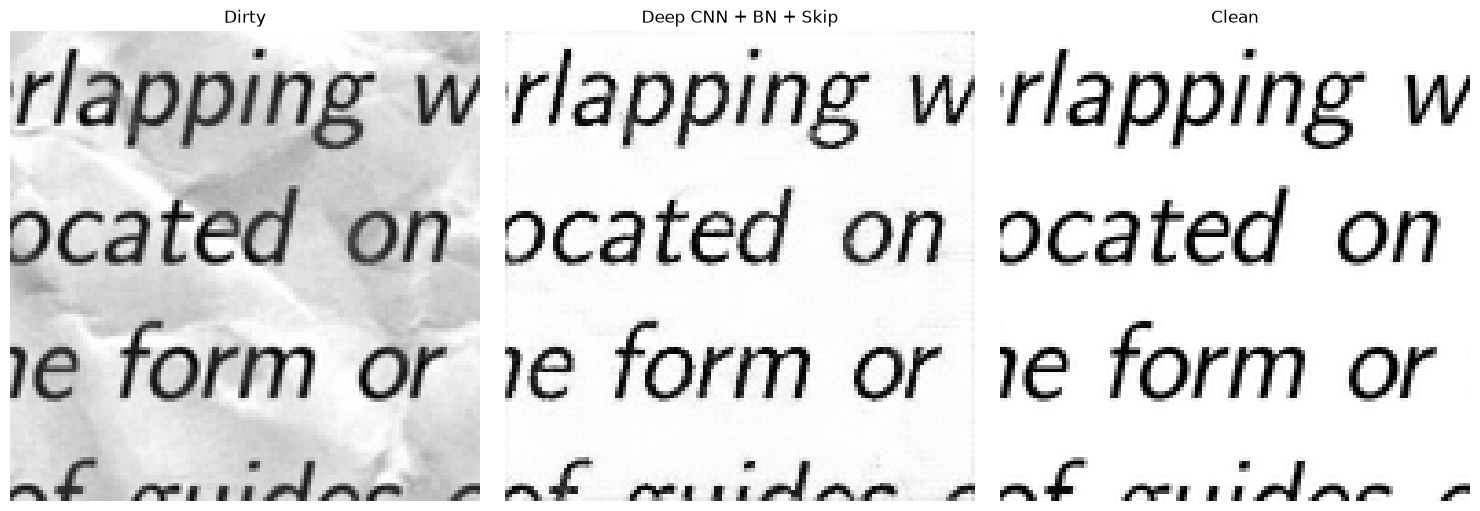

In [81]:
# ------------------------------------------------------------
# 2-3-8. Skip Connection 모델의 복원 결과 시각화
# ------------------------------------------------------------


# 배치 안에서 확인할 이미지 번호
sample_index = 0


# Matplotlib 출력을 위해 CPU로 이동
dirty_image = (
    skip_val_dirty[sample_index]
    .detach()
    .cpu()
)

restored_image = (
    skip_val_restored[sample_index]
    .detach()
    .cpu()
)

clean_image = (
    skip_val_clean[sample_index]
    .detach()
    .cpu()
)


# Dirty, Restored, Clean을 가로로 출력
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)


# 복원 전 손상 이미지
axes[0].imshow(
    dirty_image.squeeze(),
    cmap="gray"
)
axes[0].set_title("Dirty")


# Skip Connection 모델의 복원 이미지
axes[1].imshow(
    restored_image.squeeze(),
    cmap="gray"
)
axes[1].set_title("Deep CNN + BN + Skip")


# 깨끗한 정답 이미지
axes[2].imshow(
    clean_image.squeeze(),
    cmap="gray"
)
axes[2].set_title("Clean")


# 좌표축 제거
for ax in axes:
    ax.axis("off")


plt.tight_layout()
plt.show()

In [82]:
# ------------------------------------------------------------
# 2-3-9. Skip Connection 모델의 전체 검증 데이터 평가
# ------------------------------------------------------------


# 모델을 평가 모드로 설정
skip_model.eval()


# 검증 이미지별 평가 결과를 저장할 리스트
# 셀을 다시 실행할 때 중복되지 않도록 빈 리스트로 초기화
skip_rmse_values = []
skip_psnr_values = []


# 검증에서는 기울기를 계산하지 않음
with torch.no_grad():

    # 전체 검증 데이터를 배치 단위로 가져오기
    for dirty, clean in val_loader:

        # 모델과 같은 연산 장치로 이동
        dirty = dirty.to(device)
        clean = clean.to(device)


        # Skip Connection 모델로 이미지 복원
        restored = skip_model(dirty)


        # 현재 배치의 이미지를 한 장씩 평가
        for image_index in range(len(dirty)):

            # 현재 이미지의 RMSE 계산
            image_rmse = calculate_rmse(
                restored[image_index],
                clean[image_index]
            )


            # 현재 이미지의 PSNR 계산
            image_psnr = calculate_psnr(
                restored[image_index],
                clean[image_index]
            )


            # 이미지별 평가 결과 저장
            skip_rmse_values.append(image_rmse)
            skip_psnr_values.append(image_psnr)


# 검증 이미지들의 평균 RMSE
skip_rmse = np.mean(skip_rmse_values)


# 검증 이미지들의 평균 PSNR
skip_psnr = np.mean(skip_psnr_values)


# 평가 결과 출력
print("평가 이미지 수:", len(skip_rmse_values))
print(f"Skip CNN RMSE: {skip_rmse:.4f}")
print(f"Skip CNN PSNR: {skip_psnr:.2f} dB")

평가 이미지 수: 29
Skip CNN RMSE: 0.0506
Skip CNN PSNR: 25.96 dB


In [83]:
# ------------------------------------------------------------
# 2-3-10. Deep CNN과 Skip Connection 모델 성능 비교
# ------------------------------------------------------------


# RMSE는 작을수록 좋음
#
# 양수: Skip 모델의 RMSE가 감소하여 성능 향상
# 음수: Skip 모델의 RMSE가 증가하여 성능 저하
skip_rmse_improvement = deep_rmse - skip_rmse


# PSNR은 클수록 좋음
#
# 양수: Skip 모델의 PSNR이 증가하여 성능 향상
# 음수: Skip 모델의 PSNR이 감소하여 성능 저하
skip_psnr_improvement = skip_psnr - deep_psnr


print("[Deep CNN + BatchNorm]")
print(f"RMSE: {deep_rmse:.4f}")
print(f"PSNR: {deep_psnr:.2f} dB")

print()

print("[Deep CNN + BatchNorm + Skip Connection]")
print(f"RMSE: {skip_rmse:.4f}")
print(f"PSNR: {skip_psnr:.2f} dB")

print()

print("[Deep CNN 대비 Skip Connection 성능 변화]")
print(f"RMSE 개선: {skip_rmse_improvement:+.4f}")
print(f"PSNR 개선: {skip_psnr_improvement:+.2f} dB")

[Deep CNN + BatchNorm]
RMSE: 0.1474
PSNR: 16.67 dB

[Deep CNN + BatchNorm + Skip Connection]
RMSE: 0.0506
PSNR: 25.96 dB

[Deep CNN 대비 Skip Connection 성능 변화]
RMSE 개선: +0.0968
PSNR 개선: +9.29 dB


In [84]:
# ------------------------------------------------------------
# 2-3-11. Skip Connection 모델의 실험 결과 저장
# ------------------------------------------------------------


experiment_results.append(
    {
        "model": "Deep CNN + BatchNorm + Skip",
        "rmse": skip_rmse,
        "psnr": skip_psnr
    }
)


# 지금까지 저장된 결과 확인
for result in experiment_results:

    print(
        result["model"],
        f"| RMSE: {result['rmse']:.4f}",
        f"| PSNR: {result['psnr']:.2f} dB"
    )

Dirty Before Restoration | RMSE: 0.1449 | PSNR: 16.89 dB
Baseline CNN Autoencoder | RMSE: 0.0961 | PSNR: 20.41 dB
Deep CNN + BatchNorm | RMSE: 0.1474 | PSNR: 16.67 dB
Deep CNN + BatchNorm + Skip | RMSE: 0.0506 | PSNR: 25.96 dB


#### 2-4. 모델 구조 및 과적합 비교

In [85]:
# ------------------------------------------------------------
# 2-4-1. 전체 모델의 RMSE·PSNR 결과 비교
# ------------------------------------------------------------


print("=" * 75)

print(
    f"{'Model':<40}"
    f"{'RMSE':>12}"
    f"{'PSNR':>18}"
)

print("=" * 75)


for result in experiment_results:

    print(
        f"{result['model']:<40}"
        f"{result['rmse']:>12.4f}"
        f"{result['psnr']:>15.2f} dB"
    )


print("=" * 75)

Model                                           RMSE              PSNR
Dirty Before Restoration                      0.1449          16.89 dB
Baseline CNN Autoencoder                      0.0961          20.41 dB
Deep CNN + BatchNorm                          0.1474          16.67 dB
Deep CNN + BatchNorm + Skip                   0.0506          25.96 dB


##### 동동주의 질문 : 검증 세트를 나중에 빼고 진행했으니 데이터 누수가 아닌가??

- 처음 제공된 Dirty Before Restoration 모델은 144장 전체로 학습했기 때문에, 나중에 그중 29장을 검증 데이터로 정하고 그 모델을 검증한다면 데이터 누수

    - 현재 다시 만든 baseline_model은 별개의 새 모델이므로, 코드가 아래 순서로 실행됐다면 데이터 누수가 아님!!!!!!

    >> Dirty Before Restoration : model = ConvDenoiser().to(device)
    >>
    >> Baseline CNN Autoencoder : baseline_model = ConvDenoiser().to(device)



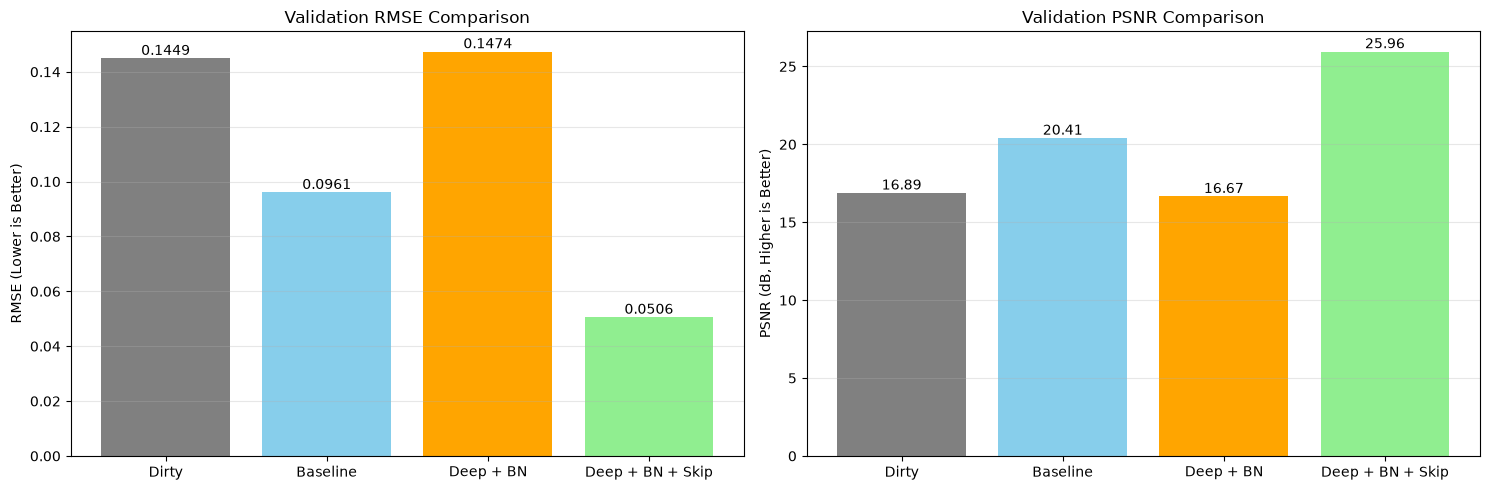

In [86]:
# ------------------------------------------------------------
# 2-4-2. 모델별 RMSE·PSNR 막대그래프
# ------------------------------------------------------------


# 그래프에 표시할 모델 이름
model_names = [
    result["model"]
    for result in experiment_results
]


# 모델별 RMSE
rmse_values = [
    result["rmse"]
    for result in experiment_results
]


# 모델별 PSNR
psnr_values = [
    result["psnr"]
    for result in experiment_results
]


# 모델 이름이 길어서 짧은 이름으로 변경
short_names = [
    "Dirty",
    "Baseline",
    "Deep + BN",
    "Deep + BN + Skip"
]


# 1행 2열 그래프 생성
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)


# ============================================================
# RMSE 그래프
# ============================================================

rmse_bars = axes[0].bar(
    short_names,
    rmse_values,
    color=["gray", "skyblue", "orange", "lightgreen"]
)

axes[0].set_title("Validation RMSE Comparison")
axes[0].set_ylabel("RMSE (Lower is Better)")
axes[0].grid(axis="y", alpha=0.3)


# 각 막대 위에 RMSE 값 표시
for bar, value in zip(rmse_bars, rmse_values):

    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )


# ============================================================
# PSNR 그래프
# ============================================================

psnr_bars = axes[1].bar(
    short_names,
    psnr_values,
    color=["gray", "skyblue", "orange", "lightgreen"]
)

axes[1].set_title("Validation PSNR Comparison")
axes[1].set_ylabel("PSNR (dB, Higher is Better)")
axes[1].grid(axis="y", alpha=0.3)


# 각 막대 위에 PSNR 값 표시
for bar, value in zip(psnr_bars, psnr_values):

    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )


plt.tight_layout()
plt.show()

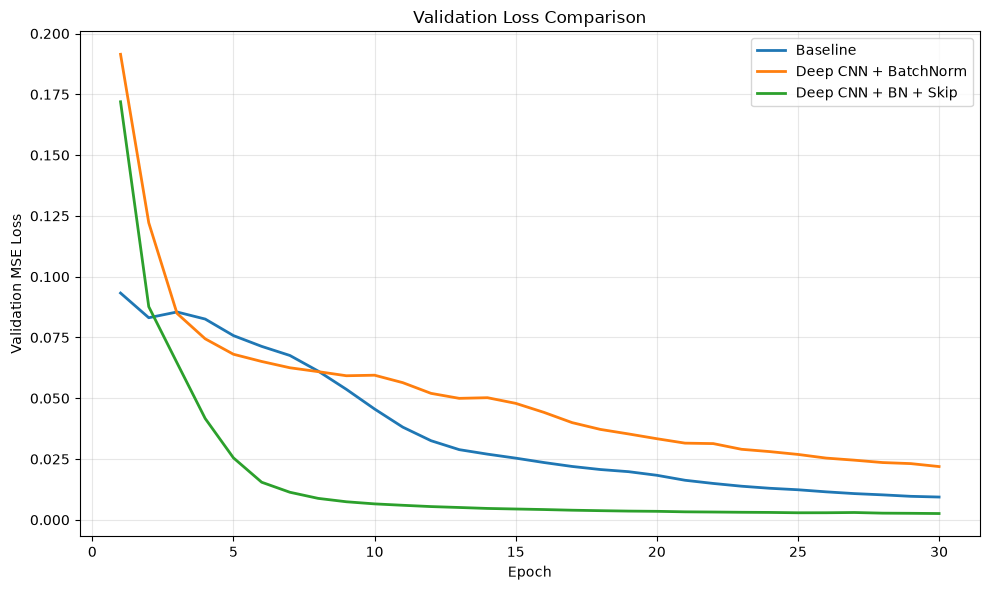

In [87]:
# ------------------------------------------------------------
# 2-4-3. 모델별 검증 손실 변화 비교
# ------------------------------------------------------------


plt.figure(figsize=(10, 6))


# Baseline 검증 손실
plt.plot(
    range(1, len(baseline_val_loss_history) + 1),
    baseline_val_loss_history,
    label="Baseline",
    linewidth=2
)


# Deep CNN 검증 손실
plt.plot(
    range(1, len(deep_val_loss_history) + 1),
    deep_val_loss_history,
    label="Deep CNN + BatchNorm",
    linewidth=2
)


# Skip Connection 모델 검증 손실
plt.plot(
    range(1, len(skip_val_loss_history) + 1),
    skip_val_loss_history,
    label="Deep CNN + BN + Skip",
    linewidth=2
)


plt.xlabel("Epoch")
plt.ylabel("Validation MSE Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### 2-5. 선택 모델의 하이퍼파라미터 튜닝

모델 구조 비교 결과, `Deep CNN + BatchNorm + Skip Connection` 모델이
가장 낮은 RMSE와 가장 높은 PSNR을 기록하였다.

따라서 해당 모델의 구조는 그대로 유지하고, 학습 과정에 영향을 주는
하이퍼파라미터 조합을 비교하여 성능을 추가로 개선한다.

#### 2-5-1. 튜닝 대상

이번 실험에서는 다음 네 가지 하이퍼파라미터를 조정한다.

| 하이퍼파라미터 | 후보값 | 의미 |
|---|---|---|
| Learning Rate | `2e-3`, `1e-3`, `5e-4` | 한 번의 가중치 갱신에서 이동하는 크기 |
| Batch Size | `16`, `32` | 한 번에 학습하는 이미지의 개수 |
| Weight Decay | `0`, `1e-4` | 가중치가 과도하게 커지는 것을 억제하는 정도 |
| Epoch | `30`, `60` | 전체 학습 데이터를 반복해서 학습하는 횟수 |

전체 조합 수는 다음과 같다.

전체 조합 수: `3 × 2 × 2 × 2 = 24개`

따라서 총 24개의 하이퍼파라미터 조합으로 모델을 각각 처음부터
학습하고, 동일한 검증 데이터를 이용해 성능을 평가한다.

#### 2-5-2. 후보값 선정 이유

##### Learning Rate

Learning Rate는 모델의 가중치를 한 번에 얼마나 크게 수정할지를 결정한다.

- `2e-3`: 기존보다 큰 학습률로, 더 빠르게 최적값에 접근할 수 있는지 확인한다.
- `1e-3`: 기존 모델에서 사용한 기준 학습률이다.
- `5e-4`: 가중치를 더 작게 수정하여 세밀한 학습이 가능한지 확인한다.

학습률이 너무 크면 손실이 불안정하게 변할 수 있고, 너무 작으면
제한된 Epoch 내에 충분히 학습하지 못할 수 있다.

##### Batch Size

Batch Size는 한 번의 가중치 갱신에 사용하는 이미지 수를 의미한다.

- `16`: 기존 실험에서 사용한 기준값이다.
- `32`: 더 많은 이미지를 사용하여 비교적 안정적인 기울기와 BatchNorm 통계를 얻을 수 있는지 확인한다.

Batch Size가 작으면 가중치가 자주 갱신되지만 학습이 불안정할 수 있고,
Batch Size가 크면 안정적인 학습이 가능하지만 Epoch당 가중치 갱신 횟수가
감소할 수 있다.

##### Weight Decay

Weight Decay는 모델의 가중치가 지나치게 커지는 것을 제한하여
과적합을 완화하는 정규화 방법이다.

- `0`: Weight Decay를 적용하지 않는 기준값이다.
- `1e-4`: 가중치에 제약을 추가했을 때 일반화 성능이 향상되는지 확인한다.

Weight Decay가 너무 크면 모델이 필요한 특징까지 충분히 학습하지
못할 수 있으므로 비교적 작은 값을 사용한다.

##### Epoch

Epoch는 전체 학습 데이터를 몇 번 반복해서 학습할지를 의미한다.

- `30`: 기존 모델들과 동일한 기준 학습 횟수이다.
- `60`: 30 Epoch에서 학습이 충분히 수렴하지 않았을 가능성을 확인하기 위한 값이다.

Epoch가 증가하면 모델이 더 충분히 학습할 수 있지만, 학습 데이터에
지나치게 맞춰져 검증 성능이 낮아지는 과적합이 발생할 수도 있다.
따라서 학습 손실과 검증 손실을 함께 확인한다.

#### 2-5-3. 실험에서 고정하는 조건

하이퍼파라미터에 따른 차이를 명확히 확인하기 위해 다음 조건은
모든 실험에서 동일하게 유지한다.

| 고정 조건 | 설정 |
|---|---|
| 모델 구조 | Deep CNN + BatchNorm + Skip Connection |
| Optimizer | Adam |
| 손실함수 | MSE Loss |
| 학습 파일 | 고정된 Train 파일 115장 |
| 검증 파일 | 고정된 Validation 파일 29장 |
| 검증 전처리 | 가운데 128×128 고정 Crop |
| Random Seed | `42` |
| 평가 지표 | RMSE, PSNR |

모든 조합은 동일한 학습·검증 파일을 사용하며, 각 실험에서는 모델을
새롭게 생성


In [88]:
# ------------------------------------------------------------
# 2-5-1. Grid Search 하이퍼파라미터 후보 설정
# ------------------------------------------------------------

from itertools import product
import gc
import time


# Learning Rate 후보
learning_rate_candidates = [
    2e-3,
    1e-3,
    5e-4
]


# Batch Size 후보
batch_size_candidates = [
    16,
    32
]


# Weight Decay 후보
weight_decay_candidates = [
    0.0,
    1e-4
]


# Epoch 후보
epoch_candidates = [
    30,
    60
]


# 모든 후보의 조합 생성
hyperparameter_combinations = list(
    product(
        learning_rate_candidates,
        batch_size_candidates,
        weight_decay_candidates,
        epoch_candidates
    )
)


print(
    "전체 하이퍼파라미터 조합 수:",
    len(hyperparameter_combinations)
)

전체 하이퍼파라미터 조합 수: 24


In [89]:
# ------------------------------------------------------------
# 2-5-2. 하나의 하이퍼파라미터 조합을 학습·평가하는 함수
# ------------------------------------------------------------

def train_grid_model(
    learning_rate,
    batch_size,
    weight_decay,
    epochs
):
    """
    전달받은 하이퍼파라미터 조합으로
    Skip Connection 모델을 처음부터 학습합니다.

    학습이 끝나면 검증 데이터의
    RMSE, PSNR, 학습 손실, 검증 손실을 반환합니다.
    """

    # ========================================================
    # 1. 난수 기준값 초기화
    # ========================================================

    # 각 실험이 가능한 한 같은 조건에서 시작하도록 설정
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    torch.manual_seed(RANDOM_SEED)


    # ========================================================
    # 2. 현재 Batch Size에 맞는 DataLoader 생성
    # ========================================================

    # 학습 데이터 순서를 재현하기 위한 Generator
    loader_generator = torch.Generator()
    loader_generator.manual_seed(RANDOM_SEED)


    current_train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=loader_generator
    )


    current_val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )


    # ========================================================
    # 3. 새로운 모델 생성
    # ========================================================

    # 각 조합은 새로운 초기 가중치부터 학습
    model = SkipConvDenoiser().to(device)


    # 복원 이미지와 Clean 이미지의 MSE 계산
    criterion = nn.MSELoss()


    # 현재 조합의 Learning Rate와 Weight Decay 적용
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )


    # Epoch별 손실 기록
    train_history = []
    val_history = []


    # ========================================================
    # 4. 모델 학습 및 검증
    # ========================================================

    for epoch in range(epochs):

        # ----------------------------------------------------
        # 학습
        # ----------------------------------------------------

        model.train()

        train_loss_sum = 0.0


        for dirty, clean in current_train_loader:

            dirty = dirty.to(device)
            clean = clean.to(device)


            # 이전 배치의 기울기 제거
            optimizer.zero_grad()


            # 이미지 복원
            restored = model(dirty)


            # 학습 손실 계산
            loss = criterion(restored, clean)


            # 기울기 계산 및 가중치 수정
            loss.backward()
            optimizer.step()


            # 현재 배치의 손실 누적
            train_loss_sum += loss.item() * len(dirty)


        # 현재 Epoch의 평균 학습 손실
        train_loss = (
            train_loss_sum
            / len(current_train_loader.dataset)
        )

        train_history.append(train_loss)


        # ----------------------------------------------------
        # 검증
        # ----------------------------------------------------

        model.eval()

        val_loss_sum = 0.0


        with torch.no_grad():

            for dirty, clean in current_val_loader:

                dirty = dirty.to(device)
                clean = clean.to(device)


                # 검증 이미지 복원
                restored = model(dirty)


                # 검증 손실 계산
                loss = criterion(restored, clean)


                # 검증 손실 누적
                val_loss_sum += loss.item() * len(dirty)


        # 현재 Epoch의 평균 검증 손실
        val_loss = (
            val_loss_sum
            / len(current_val_loader.dataset)
        )

        val_history.append(val_loss)


    # ========================================================
    # 5. 전체 검증 데이터의 RMSE·PSNR 계산
    # ========================================================

    model.eval()

    rmse_values = []
    psnr_values = []


    with torch.no_grad():

        for dirty, clean in current_val_loader:

            dirty = dirty.to(device)
            clean = clean.to(device)


            # 검증 이미지 복원
            restored = model(dirty)


            # 현재 배치의 이미지를 한 장씩 평가
            for image_index in range(len(dirty)):

                image_rmse = calculate_rmse(
                    restored[image_index],
                    clean[image_index]
                )

                image_psnr = calculate_psnr(
                    restored[image_index],
                    clean[image_index]
                )


                rmse_values.append(image_rmse)
                psnr_values.append(image_psnr)


    # 검증 이미지들의 평균 점수
    mean_rmse = np.mean(rmse_values)
    mean_psnr = np.mean(psnr_values)


    # 가장 낮았던 검증 손실과 해당 Epoch
    best_val_loss = min(val_history)

    best_epoch = (
        val_history.index(best_val_loss)
        + 1
    )


    # 현재 조합의 결과 반환
    return {
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "weight_decay": weight_decay,
        "epochs": epochs,
        "final_train_loss": train_history[-1],
        "final_val_loss": val_history[-1],
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "rmse": mean_rmse,
        "psnr": mean_psnr
    }

In [90]:
# ------------------------------------------------------------
# 2-5-3. 전체 하이퍼파라미터 조합 학습
# ------------------------------------------------------------


# 전체 실험 결과를 저장할 리스트
grid_results = []


# 전체 Grid Search 시작 시간
grid_start_time = time.time()


for experiment_index, combination in enumerate(
    hyperparameter_combinations,
    start=1
):

    # 현재 조합의 값 분리
    (
        learning_rate,
        batch_size,
        weight_decay,
        epochs
    ) = combination


    print("=" * 75)

    print(
        f"[{experiment_index:02d}/"
        f"{len(hyperparameter_combinations):02d}] "
        f"실험 시작"
    )

    print(
        f"LR={learning_rate} | "
        f"Batch={batch_size} | "
        f"Weight Decay={weight_decay} | "
        f"Epoch={epochs}"
    )


    # 현재 실험 시작 시간
    experiment_start_time = time.time()


    # 현재 조합으로 모델 학습 및 평가
    result = train_grid_model(
        learning_rate=learning_rate,
        batch_size=batch_size,
        weight_decay=weight_decay,
        epochs=epochs
    )


    # 현재 실험에 걸린 시간
    elapsed_seconds = (
        time.time()
        - experiment_start_time
    )


    # 실행 시간도 결과에 저장
    result["elapsed_seconds"] = elapsed_seconds


    # 전체 결과 리스트에 저장
    grid_results.append(result)


    print(
        f"RMSE={result['rmse']:.4f} | "
        f"PSNR={result['psnr']:.2f} dB"
    )

    print(
        f"Best Epoch={result['best_epoch']} | "
        f"Best Val Loss={result['best_val_loss']:.5f}"
    )

    print(
        f"소요 시간: "
        f"{elapsed_seconds / 60:.2f}분"
    )


    # 실험이 끝난 모델이 차지하던 메모리 정리
    gc.collect()

    if device == "cuda":
        torch.cuda.empty_cache()

    elif device == "mps":
        torch.mps.empty_cache()


# Grid Search 전체 시간
grid_elapsed_time = (
    time.time()
    - grid_start_time
)


print("=" * 75)

print(
    f"전체 Grid Search 시간: "
    f"{grid_elapsed_time / 60:.2f}분"
)

[01/24] 실험 시작
LR=0.002 | Batch=16 | Weight Decay=0.0 | Epoch=30
RMSE=0.0432 | PSNR=27.35 dB
Best Epoch=30 | Best Val Loss=0.00189
소요 시간: 0.60분
[02/24] 실험 시작
LR=0.002 | Batch=16 | Weight Decay=0.0 | Epoch=60
RMSE=0.0358 | PSNR=28.98 dB
Best Epoch=60 | Best Val Loss=0.00130
소요 시간: 1.09분
[03/24] 실험 시작
LR=0.002 | Batch=16 | Weight Decay=0.0001 | Epoch=30
RMSE=0.0440 | PSNR=27.18 dB
Best Epoch=30 | Best Val Loss=0.00195
소요 시간: 0.57분
[04/24] 실험 시작
LR=0.002 | Batch=16 | Weight Decay=0.0001 | Epoch=60
RMSE=0.0440 | PSNR=27.18 dB
Best Epoch=55 | Best Val Loss=0.00142
소요 시간: 1.01분
[05/24] 실험 시작
LR=0.002 | Batch=32 | Weight Decay=0.0 | Epoch=30
RMSE=0.0540 | PSNR=25.42 dB
Best Epoch=30 | Best Val Loss=0.00295
소요 시간: 0.55분
[06/24] 실험 시작
LR=0.002 | Batch=32 | Weight Decay=0.0 | Epoch=60
RMSE=0.0426 | PSNR=27.47 dB
Best Epoch=60 | Best Val Loss=0.00183
소요 시간: 1.03분
[07/24] 실험 시작
LR=0.002 | Batch=32 | Weight Decay=0.0001 | Epoch=30
RMSE=0.0542 | PSNR=25.36 dB
Best Epoch=29 | Best Val Loss=0.00288
소요 

In [91]:
# ------------------------------------------------------------
# 2-5-4. Grid Search 결과를 성능순으로 정렬
# ------------------------------------------------------------


# PSNR이 높은 순서로 정렬
# PSNR이 같다면 RMSE가 낮은 결과를 우선함
sorted_grid_results = sorted(
    grid_results,
    key=lambda result: (
        -result["psnr"],
        result["rmse"]
    )
)


print("=" * 120)

print(
    f"{'순위':<6}"
    f"{'LR':<12}"
    f"{'Batch':<10}"
    f"{'Weight Decay':<16}"
    f"{'Epoch':<9}"
    f"{'Best Epoch':<13}"
    f"{'RMSE':<13}"
    f"{'PSNR':<14}"
    f"{'시간(분)':<10}"
)

print("=" * 120)


for rank, result in enumerate(
    sorted_grid_results,
    start=1
):

    print(
        f"{rank:<6}"
        f"{result['learning_rate']:<12.4g}"
        f"{result['batch_size']:<10}"
        f"{result['weight_decay']:<16.4g}"
        f"{result['epochs']:<9}"
        f"{result['best_epoch']:<13}"
        f"{result['rmse']:<13.4f}"
        f"{result['psnr']:<11.2f} dB"
        f"{result['elapsed_seconds'] / 60:<10.2f}"
    )


print("=" * 120)

순위    LR          Batch     Weight Decay    Epoch    Best Epoch   RMSE         PSNR          시간(분)     
1     0.002       16        0               60       60           0.0358       28.98       dB1.09      
2     0.001       16        0               60       60           0.0400       28.02       dB1.22      
3     0.002       32        0.0001          60       60           0.0413       27.72       dB1.05      
4     0.002       32        0               60       60           0.0426       27.47       dB1.03      
5     0.002       16        0               30       30           0.0432       27.35       dB0.60      
6     0.002       16        0.0001          60       55           0.0440       27.18       dB1.01      
7     0.002       16        0.0001          30       30           0.0440       27.18       dB0.57      
8     0.0005      16        0               60       60           0.0475       26.51       dB1.70      
9     0.0005      16        0.0001          60       57         

In [92]:
# ------------------------------------------------------------
# 2-5-5. 최고 성능 하이퍼파라미터 선택
# ------------------------------------------------------------


# 정렬 결과의 첫 번째 조합
best_grid_result = sorted_grid_results[0]


# 최적 하이퍼파라미터 저장
best_learning_rate = best_grid_result[
    "learning_rate"
]

best_batch_size = best_grid_result[
    "batch_size"
]

best_weight_decay = best_grid_result[
    "weight_decay"
]

best_epochs = best_grid_result[
    "epochs"
]


print("[최고 성능 하이퍼파라미터]")

print(
    "Learning Rate:",
    best_learning_rate
)

print(
    "Batch Size:",
    best_batch_size
)

print(
    "Weight Decay:",
    best_weight_decay
)

print(
    "Epoch:",
    best_epochs
)

print(
    "검증 손실이 가장 낮았던 Epoch:",
    best_grid_result["best_epoch"]
)

print(
    f"Validation RMSE: "
    f"{best_grid_result['rmse']:.4f}"
)

print(
    f"Validation PSNR: "
    f"{best_grid_result['psnr']:.2f} dB"
)

[최고 성능 하이퍼파라미터]
Learning Rate: 0.002
Batch Size: 16
Weight Decay: 0.0
Epoch: 60
검증 손실이 가장 낮았던 Epoch: 60
Validation RMSE: 0.0358
Validation PSNR: 28.98 dB


##### Grid Search 결과 분석

총 24개의 하이퍼파라미터 조합을 비교한 결과, 가장 높은 성능을 기록한 조합은 다음과 같다.

| 하이퍼파라미터 | 선택값 |
|---|---:|
| Learning Rate | `2e-3` |
| Batch Size | `16` |
| Weight Decay | `0` |
| Epoch | `60` |
| Best Epoch | `60` |
| RMSE | `0.0358` |
| PSNR | `28.98 dB` |

현재 평가 결과는 검증 파일 29장의 전체 이미지가 아니라, 각 이미지의 가운데에서 추출한 `128×128` 고정 패치를 기준으로 한다.


##### 튜닝 전후 성능 비교

| 모델 | RMSE ↓ | PSNR ↑ |
|---|---:|---:|
| Baseline CNN Autoencoder | 0.0961 | 20.41 dB |
| 튜닝 전 Skip 모델 | 0.0506 | 25.96 dB |
| 튜닝 후 Skip 모델 | **0.0358** | **28.98 dB** |

튜닝 후 Skip 모델은 튜닝 전 모델보다 RMSE가 약 29.2% 감소했고, PSNR은 3.02 dB 증가했다.

또한 Baseline과 비교하면 RMSE가 약 62.7% 감소했고, PSNR은 8.57 dB 증가했다.

따라서 하이퍼파라미터 튜닝이 문서 이미지의 복원 성능을 개선하는 데 효과가 있었음을 확인하였다.


##### 하이퍼파라미터별 결과 경향

###### 1. Learning Rate

가장 높은 성능을 기록한 Learning Rate는 `2e-3`이다.

후보 중 비교적 큰 학습률에서 좋은 결과가 나타난 것으로 보아, 현재 모델은 `1e-3`이나 `5e-4`보다 `2e-3`에서 제한된 Epoch 안에 더 빠르게 수렴한 것으로 판단된다.

다만 `2e-3`은 현재 탐색 범위에서 가장 큰 값이므로, 추가 실험이 필요하다면 `1.5e-3`, `2e-3`, `2.5e-3`처럼 최고값 주변만 좁게 비교할 수 있다.


###### 2. Batch Size

상위 2개 조합은 모두 Batch Size `16`을 사용했다.

현재 학습 데이터는 115장으로 많지 않기 때문에 Batch Size `16`이 `32`보다 한 Epoch 안에서 가중치를 더 자주 수정할 수 있다는 점이 성능 향상에 영향을 준 것으로 보인다.

또한 Batch Size `16`은 BatchNorm을 사용하면서도 현재 데이터 규모에서 충분히 학습 가능한 크기였다고 판단된다.

따라서 최종 모델의 Batch Size는 `16`을 우선 선택한다.


###### 3. Weight Decay

가장 높은 성능을 기록한 상위 2개 조합에서는 Weight Decay를 적용하지 않았다.

- 1위 Weight Decay: `0`
- 2위 Weight Decay: `0`

현재 데이터와 모델에서는 `1e-4`의 Weight Decay가 가중치 학습을 지나치게 제한했을 가능성이 있다.

따라서 최종 모델에서는 Weight Decay를 `0`으로 설정한다.

이는 모든 문제에서 Weight Decay가 불필요하다는 뜻이 아니라, 이번 데이터와 실험 범위에서 `0`이 가장 좋은 결과를 기록했다는 의미이다.


###### 4. Epoch

대체로 30 Epoch보다 60 Epoch에서 높은 성능을 기록한 조합이 많았다.

가장 좋은 모델은 60 Epoch에서 가장 낮은 검증 손실을 기록했다.

- 설정 Epoch: `60`
- Best Epoch: `60`

이는 해당 모델이 60 Epoch까지 뚜렷하게 과적합되지 않았으며, 학습이 계속 진행되고 있었을 가능성을 보여준다.

반면 일부 조합에서는 설정한 마지막 Epoch보다 앞선 시점에서 가장 낮은 검증 손실을 기록했다.

예를 들어 일부 60 Epoch 조합은 55 또는 57 Epoch에서 가장 낮은 검증 손실을 기록했다.

이는 학습 후반에 검증 성능이 더 이상 개선되지 않거나 약간 저하될 수 있음을 의미한다.

따라서 최종 학습에서는 Epoch를 무조건 증가시키기보다 Early Stopping을 적용하여 검증 성능이 가장 좋았던 시점의 가중치를 사용하는 것이 적절하다.


##### Grid Search 결과 결론

이번 Grid Search에서는 다음 설정이 가장 좋은 성능을 기록했다.

- Learning Rate: `2e-3`
- Batch Size: `16`
- Weight Decay: `0`
- Epoch: `60`
- RMSE: `0.0358`
- PSNR: `28.98 dB`

따라서 위 설정을 최종 모델의 기준 하이퍼파라미터로 선택한다.

다만 24개의 조합을 동일한 검증 데이터로 반복 평가했기 때문에, 새로운 조합을 지나치게 많이 추가하면 검증 데이터에 간접적으로 과적합될 수 있다.

따라서 새로운 대규모 Grid Search를 추가하기보다 현재 최적 설정을 기반으로 학습 전략과 복원 방식을 개선한다.


#### 추가 성능 개선 방향

##### 1. Learning Rate Scheduler

현재 모델은 학습이 끝날 때까지 동일한 Learning Rate를 사용한다.

Learning Rate Scheduler를 적용하면 학습 초반에는 비교적 큰 학습률로 빠르게 학습하고, 검증 손실이 더 이상 감소하지 않을 때 학습률을 낮춰 최적점 주변을 세밀하게 탐색할 수 있다.

예상되는 학습 과정은 다음과 같다.

1. 초기 Learning Rate `2e-3`으로 학습한다.
2. 검증 손실이 일정 기간 개선되지 않으면 Learning Rate를 감소시킨다.
3. 감소한 Learning Rate로 가중치를 더 세밀하게 조정한다.

고정된 Learning Rate만 사용하는 것보다 학습 후반의 성능을 개선할 가능성이 있다.


##### 2. Early Stopping

Grid Search에서는 각 조합을 30 또는 60 Epoch까지 학습한 뒤 마지막 모델을 평가했다.

하지만 일부 조합은 마지막 Epoch보다 앞선 시점에서 가장 낮은 검증 손실을 기록했다.

따라서 최종 모델에서는 다음 방법을 적용한다.

1. 최대 Epoch를 충분히 크게 설정한다.
2. 매 Epoch마다 검증 손실을 확인한다.
3. 검증 손실이 가장 낮아질 때 모델의 가중치를 저장한다.
4. 일정 기간 동안 검증 손실이 개선되지 않으면 학습을 종료한다.
5. 마지막 Epoch의 모델이 아니라 가장 좋은 검증 성능을 기록한 모델을 사용한다.

이를 통해 불필요한 학습을 줄이고 과적합 가능성을 낮출 수 있다.


##### 3. 손실함수 변경

현재 모델은 MSE Loss를 사용한다.

MSE는 전체 픽셀 오차와 PSNR을 개선하는 데 효과적이지만, 복원된 글자의 경계를 흐리게 만들 수 있다.

이를 개선하기 위해 MSE와 L1 Loss를 결합하는 방법을 추가로 비교할 수 있다.

사용할 수 있는 결합 손실은 `0.7 × MSE + 0.3 × L1`이다.

MSE는 전체적인 픽셀 오차를 줄이고, L1 Loss는 글자와 윤곽을 비교적 선명하게 보존하는 데 도움을 줄 수 있다.

손실함수를 변경한 결과는 RMSE와 PSNR뿐만 아니라 실제 복원 이미지의 글자 선명도도 함께 비교해야 한다.


##### 4. 다운샘플링 횟수 감소

현재 Skip 모델은 입력 이미지를 다음과 같이 네 번 축소한다.

`128 → 64 → 32 → 16 → 8`

Skip Connection이 Encoder의 중간 특징을 Decoder에 전달하지만, `8×8`까지 압축하는 과정에서 작은 글자와 얇은 윤곽 정보가 손실될 수 있다.

따라서 다운샘플링을 다음처럼 세 번만 수행하는 구조를 추가로 실험할 수 있다.

`128 → 64 → 32 → 16`

압축 정도를 줄이면 잠재 표현의 공간 정보가 더 많이 유지되므로 문서 글자를 복원하는 데 도움이 될 가능성이 있다.


##### 5. Residual Learning

현재 모델은 Dirty 이미지를 입력받아 Clean 이미지 전체를 직접 생성한다.

Residual Learning을 적용하면 모델이 전체 이미지를 다시 만드는 대신 Dirty 이미지에서 제거해야 할 오염이나 Dirty와 Clean 사이의 차이를 예측하도록 학습할 수 있다.

복원 과정은 다음과 같이 표현할 수 있다.

`복원 이미지 = Dirty 이미지 - 모델이 예측한 오염`

Dirty와 Clean 이미지는 대부분의 영역이 유사하고 얼룩이나 손상 부분에서만 차이가 있으므로, 차이 정보만 학습하는 방식이 문서 복원에 효과적일 수 있다.


##### 6. Test-Time Augmentation

최종 모델 학습 후에는 Test-Time Augmentation을 적용할 수 있다.

원본 이미지와 좌우 반전된 이미지를 각각 복원한 뒤, 반전된 결과를 원래 방향으로 되돌리고 두 복원 결과의 평균을 계산한다.

TTA는 모델을 다시 학습하지 않고 여러 예측을 평균 내어 복원 결과를 안정화하는 방법이다.

다만 추론 시간이 증가하고 항상 성능이 향상되는 것은 아니므로, 검증 데이터에서 일반 추론과 TTA 추론의 RMSE 및 PSNR을 먼저 비교해야 한다.


##### 추가 실험 진행 방향

새로운 대규모 하이퍼파라미터 탐색보다는 다음 순서로 실험을 진행한다.

1. Grid Search에서 선택한 최적 하이퍼파라미터를 사용한다.
2. Learning Rate Scheduler와 Early Stopping을 적용한다.
3. 검증 성능이 가장 좋았던 모델의 가중치를 저장한다.
4. 최종 검증 이미지를 전체 크기로 복원하여 평가한다.
5. 필요하다면 MSE와 MSE+L1 손실함수를 비교한다.
6. 필요하다면 일반 추론과 TTA 추론을 비교한다.

모델 구조를 추가로 개선할 시간이 있다면 다운샘플링 횟수를 네 번에서 세 번으로 줄이거나 Residual Learning을 적용하는 실험을 진행한다.

#### 2-6. 최종 모델 선정

### 3. 최종 평가

#### 3-1. 전체 모델 결과 비교

#### 3-2. 최종 모델 선정 근거 작성

#### 3-3. Test 이미지 복원

#### 3-4.실패 사례 분석

#### 3-5. 결론 및 한계 정리

<!-- ### 3. 최종 평가 -->

---
# Part 2. (심화) 심전도 이상 탐지 — LSTM 오토인코더

# 무리에요!!!!!!! ㅠㅠ 

# 나중에 심화 할 수 있다면... 해보고 피드백 부탁드려도 될까요..?ㅠㅠ

심화 문제는 채점에 포함되지 않아요. 여유가 될 때 도전해 봅시다.

이번에는 순서가 있는 데이터입니다. **정상 심전도(ECG) 신호만으로** LSTM 오토인코더를 학습시킵니다.
정상 패턴만 배운 모델은 이상 신호를 제대로 복원하지 못하므로, **복원 오차가 큰 신호를 이상 심박으로 판정**할 수 있어요.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("http://storage.googleapis.com/download.tensorflow.org/data/ecg.csv", header=None)
data = df.iloc[:, :-1].values.astype("float32")  # (4998, 140) — 신호 하나당 140 타임스텝
labels = df.iloc[:, -1].values.astype(int)       # 1: 정상, 0: 이상

X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42, stratify=labels
)

# 훈련 데이터 기준으로 0~1 정규화
mn, mx = X_train.min(), X_train.max()
X_train = (X_train - mn) / (mx - mn)
X_test = (X_test - mn) / (mx - mn)

# 핵심: 정상 신호만 골라 학습 세트를 만듭니다.
X_train_normal = X_train[y_train == 1]
print("전체 훈련:", X_train.shape, "| 정상만:", X_train_normal.shape, "| 테스트:", X_test.shape)

In [ ]:
# 정상 신호와 이상 신호를 눈으로 비교해 봅시다.
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(X_train[y_train == 1][0]); axes[0].set_title("normal")
axes[1].plot(X_train[y_train == 0][0]); axes[1].set_title("anomaly")
plt.show()

## 2-1. LSTM 오토인코더 설계
인코더 LSTM의 **마지막 hidden state**가 신호 전체를 요약한 잠재 벡터가 됩니다.
디코더는 이 벡터를 타임스텝 수만큼 반복해 입력받아, 원래 신호를 되살려 냅니다.

In [ ]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, seq_len=140, n_features=1, hidden_size=64):
        super().__init__()
        self.seq_len = seq_len
        self.encoder = nn.LSTM(n_features, hidden_size, batch_first=True)
        self.decoder = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.output_layer = nn.Linear(hidden_size, n_features)

    def forward(self, x):
        # x: (batch, 140, 1)
        _, (h, _) = self.encoder(x)                          # h: (1, batch, 64) — 신호 전체의 요약
        z = h[-1]                                            # (batch, 64)
        dec_in = z.unsqueeze(1).repeat(1, self.seq_len, 1)   # (batch, 140, 64)
        out, _ = self.decoder(dec_in)                        # (batch, 140, 64)
        return self.output_layer(out)                        # (batch, 140, 1)


ae = LSTMAutoencoder().to(device)
print(ae)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

X_train_normal_t = torch.tensor(X_train_normal).unsqueeze(-1)  # (N, 140, 1)
normal_loader = DataLoader(TensorDataset(X_train_normal_t), batch_size=128, shuffle=True)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(ae.parameters(), lr=1e-3)

EPOCHS = 100
for epoch in range(EPOCHS):
    ae.train()
    epoch_loss = 0.0
    for (xb,) in normal_loader:
        xb = xb.to(device)
        optimizer.zero_grad()
        loss = criterion(ae(xb), xb)  # 입력을 그대로 복원하도록 학습
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    if (epoch + 1) % 20 == 0:
        print(f"epoch {epoch + 1:3d} | loss {epoch_loss / len(X_train_normal_t):.5f}")

## 2-2. 복원 오차 분포와 임계값
정상 훈련 신호의 복원 오차 분포를 기준으로 임계값을 정합니다.
Baseline은 `평균 + 2×표준편차`를 사용했지만, 백분위수(예: 95%) 등 다른 기준도 실험해 보세요.

In [ ]:
def recon_errors(model, X):
    """신호별 복원 오차(MSE)를 계산합니다."""
    model.eval()
    x = torch.tensor(X).unsqueeze(-1)
    with torch.no_grad():
        pred = model(x.to(device)).cpu()
    return ((pred - x) ** 2).mean(dim=(1, 2)).numpy()


train_errors = recon_errors(ae, X_train_normal)
threshold = train_errors.mean() + 2 * train_errors.std()
print(f"임계값: {threshold:.5f}")

# 테스트 세트에서 정상/이상의 오차 분포가 갈라지는지 확인해 봅시다.
test_errors = recon_errors(ae, X_test)
plt.figure(figsize=(8, 4))
plt.hist(test_errors[y_test == 1], bins=50, alpha=0.6, label="normal")
plt.hist(test_errors[y_test == 0], bins=50, alpha=0.6, label="anomaly")
plt.axvline(threshold, color="red", linestyle="--", label="threshold")
plt.xlabel("reconstruction error"); plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# 오차가 임계값보다 크면 이상(0), 작으면 정상(1)으로 판정합니다.
y_pred = (test_errors <= threshold).astype(int)
print(classification_report(y_test, y_pred, target_names=["anomaly(0)", "normal(1)"], digits=3))

In [ ]:
# 모델이 이상 신호를 '못' 복원하는 모습을 직접 확인해 봅시다.
def plot_reconstruction(model, signal, title):
    x = torch.tensor(signal).reshape(1, -1, 1)
    with torch.no_grad():
        pred = model(x.to(device)).cpu().squeeze()
    plt.plot(signal, label="original")
    plt.plot(pred, label="reconstructed")
    plt.fill_between(range(len(signal)), signal, pred, alpha=0.3)
    plt.title(title); plt.legend()


plt.figure(figsize=(12, 3.5))
plt.subplot(1, 2, 1); plot_reconstruction(ae, X_test[y_test == 1][0], "normal")
plt.subplot(1, 2, 2); plot_reconstruction(ae, X_test[y_test == 0][0], "anomaly")
plt.show()

## 2-3. 더 실험해 볼 것들
- 임계값 기준을 바꿔 보며 Precision과 Recall이 어떻게 움직이는지 관찰하기
- hidden size, 층 수를 조절하거나 LSTM을 GRU로 바꿔 비교하기
- 인코더를 양방향(bidirectional)으로 바꾸면 복원 품질이 달라지는지 확인하기

기본 미션과 심화 문제 모두 하나의 노트북에 담아 `05_{팀명}_{성함}.ipynb`로 제출해 주세요.